### TalentPulse Salary Prediction

***Business objective:*** prepare a trustworthy modeling table for a supervised regression pipeline that predicts average salary and can be evaluated against the legacy benchmark of $18,500 MAE.

#### Phase 1: Data Validation, Cleaning, and Exploratory Data Analysis
**Goal**
- validate the shape, schema, grain, and quality of the jobs dataset;
- explain why missing target values must not be median-imputed;
- standardize local-country salaries to a common USD target;
- identify salary-unit problems, invalid experience values, and near-duplicate postings;
- parse skills and create transparent engineered features;
- answer the case study's first EDA questions with reproducible charts;
- export leakage-safe training candidates, an unlabeled scoring pool, and a review queue.

### 1. Setup
#### Data architecture
To keep layers separate, which makes this work reproducible and prevents accidental edits of the raw data, I will use a small medallion-style architecture:
- Bronze: the unchanged raw CSV.
- Silver: all records, cleaned and enriched, with quality flags.
- Gold: task-specific training and scoring tables.


In [1]:
# Import Libraries

import numpy as np                   # Provides efficient numerical arrays and maths operations
import pandas as pd                  # Load, clean, transform, summarize, and analyze tabular data
import matplotlib.pyplot as plt      # Creates customized plots     
import seaborn as sns                # Create stat visualization
from IPython.display import display  # Render DataFrames in Jupyter 
from scipy import stats              # Stat tests and probability distributions (t-tests, corr, n-test)
import missingno as msno
import platform
from matplotlib.ticker import StrMethodFormatter
from matplotlib.patches import Patch

from pathlib import Path             # Create and manage my file paths in a portable way
import re                            # Search, extract, validate, or clean text with regular expressions
import ast

# Machine Learning 
from sklearn.base import clone
from sklearn.model_selection import train_test_split         # To train and test dataset
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    StratifiedKFold,
    cross_val_predict,
    cross_validate,
    train_test_split,
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error, 
    root_mean_squared_error, 
    r2_score,
    mean_squared_error)                         # Evaluation matrice
from sklearn.linear_model import LinearRegression                                   # Algorithm for numerical values
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.inspection import permutation_importance



print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [2]:
# Find my project root whether Jupyter starts from root or Notebook
print(Path.cwd())

C:\Users\tatej\OneDrive\10Alytics\Python\Machine Learning\Final Capstone Project


In [3]:
# Create Directory
PROJECT_ROOT = Path.cwd().resolve()

RAW_DATA_PATH = PROJECT_ROOT / "jobs_dataset.csv"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Load original data
df_raw = pd.read_csv(RAW_DATA_PATH)

# Perform all cleaning and analysis on a Working Copy
df = df_raw.copy(deep=True)

pd.set_option("display.max_columns", 30)                             # Display max 30 columns
pd.set_option("display.float_format", lambda value: f"{value:,.2f}") # Format my floats


print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Raw source: {RAW_DATA_PATH}")

Python: 3.13.9
pandas: 2.3.3
Project root: C:\Users\tatej\OneDrive\10Alytics\Python\Machine Learning\Final Capstone Project
Raw source: C:\Users\tatej\OneDrive\10Alytics\Python\Machine Learning\Final Capstone Project\jobs_dataset.csv


In [4]:
# Load and display selected columns of the Bronze data
raw = pd.read_csv(RAW_DATA_PATH, encoding="utf-8")
print(f"Rows: {raw.shape[0]:,}")
print(f"Columns: {raw.shape[1]}")
display(
    raw[
        ["job_id", "job_title", "company", "country",
        "job_level", "is_remote", "salary_avg", "has_salary"]
    ].head(5)
)

Rows: 4,653
Columns: 17


,job_id,job_title,company,country,job_level,is_remote,salary_avg,has_salary
0,5710345523,data scientist,Empnéo ICT,India,Mid,False,NaN,False
1,5676535670,data scientist,ADM,India,Mid,False,NaN,False
2,5705677339,data scientist,v4c.ai,India,Mid,False,NaN,False
3,5689758521,data scientist,Kotak Mahindra Bank,India,Mid,False,NaN,False
4,5709942304,data scientist,Whitefield Careers,India,Mid,False,NaN,False


In [5]:
# View all columns and use output to build a dtype schema
df.columns

Index(['job_id', 'job_title', 'company', 'location', 'salary_min',
       'salary_max', 'description', 'country', 'search_keyword',
       'experience_required', 'degree_required', 'skills', 'num_skills',
       'job_level', 'is_remote', 'salary_avg', 'has_salary'],
      dtype='object')

In [6]:
# Build Schema check DataFrame and list all the expected columns in the dataset
expected_columns = ['job_id', 'job_title', 'company', 'location', 'salary_min',
       'salary_max', 'description', 'country', 'search_keyword',
       'experience_required', 'degree_required', 'skills', 'num_skills',
       'job_level', 'is_remote', 'salary_avg', 'has_salary']

schema_check = pd.DataFrame(
    {
        "expected": expected_columns,
        "present": [column in raw.columns for column in expected_columns],
        "dtype": [
            str(raw[column].dtype) if column in raw.columns else "missing"
            for column in expected_columns
        ],
    }
)

print(f"Expected shape from case study: 4,653 rows x 17 columns")
print(f"Observed shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
print(f"Unique job_id: {raw['job_id'].is_unique}")
print(f"Exact duplicate rows: {raw.duplicated().sum():,}")
display(schema_check)

Expected shape from case study: 4,653 rows x 17 columns
Observed shape: 4,653 rows x 17 columns
Unique job_id: True
Exact duplicate rows: 0


,expected,present,dtype
0,job_id,True,int64
1,job_title,True,object
2,company,True,object
3,location,True,object
4,salary_min,True,float64
5,salary_max,True,float64
6,description,True,object
7,country,True,object
8,search_keyword,True,object
9,experience_required,True,float64


### Inspect & Clean the data

#### Checking Missingness
##### Build Compact data-quality profile
- To inspect the completeness and cardinality of the data before cleaning.
- To evaluate missingness in the target (salary_avg) that will be treated differently from missingness in other columns 

#### Standardize text formatting

In [7]:
# Standardize whitespace across all text columns
# to replace repeated spaces, tabs, and line breaks with one space,
# then remove spaces from the beginning & the end of each value.
# Normal single spaces & missing values are preserved.

text_columns = df.select_dtypes(include=["object", "string"]).columns

for column in text_columns:
    df[column] = (
        df[column]
        .astype("string")                       # Keep values as text
        .str.replace(r"\s+", " ", regex=True)   # Replace repeated whitespace
        .str.strip()                            # Remove spaces at both ends
    )

**Standardizing Text Columns:**

Whitespace was standardized across all text columns by replacing repeated spaces, tabs, and line breaks with a single space and removing spaces from the beginning and end of each value. This improves consistency without changing normal spaces between words or replacing missing values.

#### Validation Check

In [8]:
# Validate that the country column contains exactly the five expected countries.
# The check fails if a country is missing, misspelled, differently capitalized,
# contains a missing value, or includes an unexpected country.

assert set(df["country"].unique()) == {
    "USA",
    "UK",
    "Canada",
    "India",
    "Australia",
}, "The country column contains missing or unexpected values."


# Validate that job_level contains exactly the four expected categories.
# The check fails if a level is missing, misspelled, differently capitalized,
# contains a missing value, or includes an unexpected category.

assert set(df["job_level"].unique()) == {
    "Junior",
    "Mid",
    "Senior",
    "Lead",
}, "The job_level column contains missing or unexpected values."

# Remote status should contain only Boolean values
assert df["is_remote"].isin([True, False]).all(), \
    "The is_remote column contains invalid values."


# Salary values should be positive when present
assert (
    df["salary_avg"].isna() | df["salary_avg"].gt(0)
).all(), "Non-positive salary values were found."


# Minimum salary should not be greater than maximum salary
assert (
    df["salary_min"].isna() | df["salary_max"].isna()
    | df["salary_min"].le(df["salary_max"])
).all(), "Some minimum salaries exceed maximum salaries."



**Validating Important Fields:**

Different columns require different validation rules. `country` and `job_level` were checked against fixed expected categories of five countries and four job levels because they have small, controlled value sets. Boolean, salary, and text columns were validated using rules appropriate to their data types and meanings.

#### Clean duplicates

,dtype,missing_count,missing_pct,distinct_count
experience_required,float64,4166,89.53,43
salary_max,float64,2358,50.68,1832
salary_avg,float64,2354,50.59,1901
salary_min,float64,2354,50.59,1825
company,object,1,0.02,1852
job_id,int64,0,0.00,4653
description,object,0,0.00,3361
job_title,object,0,0.00,1513
location,object,0,0.00,833
skills,object,0,0.00,51


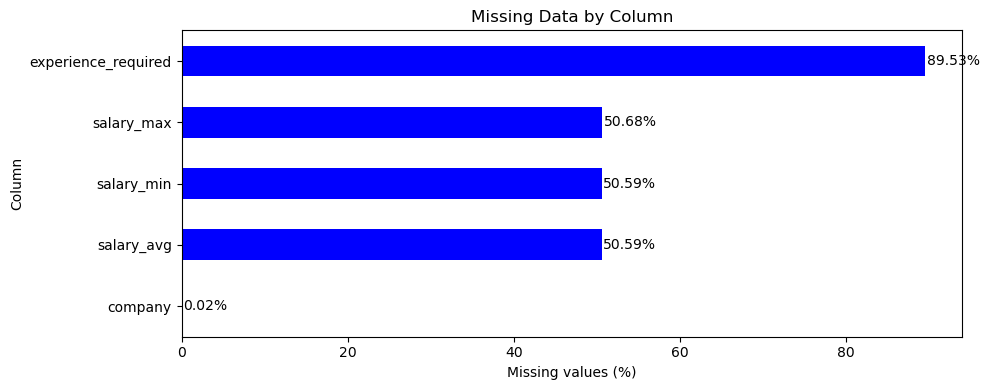

In [9]:
# Create the data-quality summary table

# Check data type of each column
data_type = raw.dtypes.astype(str)

# Count missing values in each column
missing_count = raw.isna().sum()

# Calculate percentage of missing values
missing_pct = (raw.isna().sum() / len(raw)) * 100
missing_pct = missing_pct.round(2)

# Count unique values in each column
distinct_count = raw.nunique(dropna=False)


qlty_profile = pd.DataFrame({
    "dtype": data_type,
    "missing_count": missing_count,
    "missing_pct": missing_pct,
    "distinct_count": distinct_count
}).sort_values(["missing_pct", "distinct_count"], ascending=[False, False])

display(qlty_profile)

# Visualize how complete each column is
missing_data = qlty_profile[qlty_profile["missing_pct"] > 0].sort_values(
    "missing_pct"
)

ax = missing_data["missing_pct"].plot(
    kind="barh",
    figsize=(10, 4),
    color="blue"
)

ax.set_title("Missing Data by Column")
ax.set_xlabel("Missing values (%)")
ax.set_ylabel("Column")

# Display values on graph
for bar in ax.patches:
    value = bar.get_width()
    ax.text(
        value + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

**Insight:** 

`experience_required` is missing for most rows, while a zero-length skills list may mean "nothing was found to be missing when parsing" rather than "the job requires no skills." 

**Preserve and assess experience information**

The `experience_required` column contains 89.53% of missing job postings and contains unusually large values that may represent months rather than years.
Rather than dropping the column will be retained in the Silver dataset for further investigation and secondary analysis. It will not be included in the initial regression model until its units and reliability have been investigated.

**Note:**

Since ´experience_required´ is the number of years of experience required for the role, there are values that look implausible. Therefore, we will categorize values that are above 35 years of work experience as the threshold and flag them as plausible values.

In [10]:
# Convert experience_required to numeric
df["experience_required"] = pd.to_numeric(
    df["experience_required"], errors="coerce"
)

# Categorize missing values
df["experience_missing"] = (df["experience_required"].isna())

# Flag unrealistic experience (>35 years) values as invalid
df["experience_invalid"] = df["experience_required"] > 35

# Replace unrealistic values with missing
df.loc[df["experience_invalid"], "experience_required"] = np.nan

print("Invalid experience values:", df["experience_invalid"].sum())
print("Missing experience values after cleaning:", df["experience_missing"].sum())
print(df["experience_required"].describe())

Invalid experience values: 55
Missing experience values after cleaning: 4166
count   432.00
mean      8.06
std       5.91
min       1.00
25%       5.00
50%       6.00
75%      10.00
max      35.00
Name: experience_required, dtype: float64


**Cleaning and Categorizing Experience:**

Experience values between 0 and 30 are provisionally retained as plausible years of experience. Values outside this range are excluded from the cleaned field but preserved in the original column for auditing.

Two separate indicators distinguish genuinely missing values from reported values rejected by the cleaning rule. Valid experience values are then grouped into four interpretable tiers for EDA and optional modelling.

Because the original experience extraction may contain errors and exhibit substantial missingness, it is being treated as experimental rather than automatically included in the baseline model.

In [11]:
print(df.columns.tolist())

['job_id', 'job_title', 'company', 'location', 'salary_min', 'salary_max', 'description', 'country', 'search_keyword', 'experience_required', 'degree_required', 'skills', 'num_skills', 'job_level', 'is_remote', 'salary_avg', 'has_salary', 'experience_missing', 'experience_invalid']


In [12]:
print("Originally missing:")
print(df["experience_missing"].value_counts())

print("\nInvalid experience:")
print(df["experience_invalid"].value_counts())

Originally missing:
experience_missing
True     4166
False     487
Name: count, dtype: int64

Invalid experience:
experience_invalid
False    4598
True       55
Name: count, dtype: int64


In [13]:
display(
    df.loc[
        df["experience_invalid"],
        ["experience_required", "experience_missing", "experience_invalid"]
    ]
)

,experience_required,experience_missing,experience_invalid
6,NaN,False,True
83,NaN,False,True
87,NaN,False,True
229,NaN,False,True
301,NaN,False,True
310,NaN,False,True
314,NaN,False,True
323,NaN,False,True
344,NaN,False,True
533,NaN,False,True


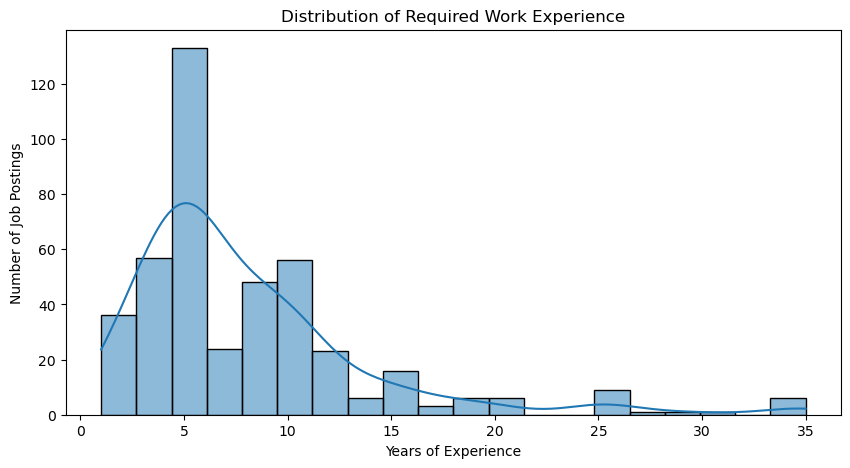

In [14]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="experience_required",
    bins=20,
    kde=True
)

plt.title("Distribution of Required Work Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Number of Job Postings")

plt.show()

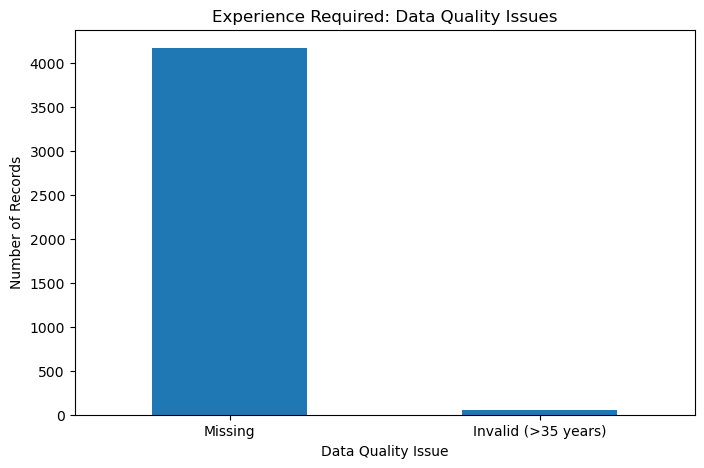

In [15]:
experience_quality = pd.Series({
    "Missing": df["experience_missing"].sum(),
    "Invalid (>35 years)": df["experience_invalid"].sum()
})

experience_quality.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Experience Required: Data Quality Issues")
plt.xlabel("Data Quality Issue")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)

plt.show()

#### Checking Duplicates

In [16]:
# Identify repeated postings using the main advertisement details
duplicate_columns = [
    "job_title",
    "company",
    "location",
    "country",
    "description",
]

# Creating a duplicate-checking dataset
duplicate_check = df.copy()

# Create the Boolean mask from duplicate_check
repeated_postings = duplicate_check.duplicated(
    subset=duplicate_columns,
    keep=False,
)

# Display the possible repeated postings for inspection
display(
    df.loc[
        repeated_postings,
        [            
            "job_title",
            "company",
            "location",
            "country",
            "skills",
            "job_level",
            "is_remote",
            "salary_avg",
        ]
    ].sort_values(["company", "job_title"])
)


,job_title,company,location,country,skills,job_level,is_remote,salary_avg
3661,healthcare business analyst,ARC Business Solutions,"Calgary, Calgary region",Canada,[],Mid,False,NaN
3662,healthcare business analyst,ARC Business Solutions,"Calgary, Calgary region",Canada,[],Mid,False,NaN
2617,machine learning engineer ii behavioral securi...,Abnormal,UK,UK,['machine learning'],Mid,False,"107,784.87"
2621,machine learning engineer ii behavioral securi...,Abnormal,UK,UK,['machine learning'],Mid,False,"95,008.02"
1349,lead data engineer,Capital One,"Pimmit, Fairfax County",USA,[],Lead,False,"203,131.94"
...,...,...,...,...,...,...,...,...
2594,"staff machine learning engineer, simulation",Waymo,"London, UK",UK,[],Mid,False,"156,000.00"
3409,machine learning engineer iii / senior machine...,Workday,"Toronto, Ontario",Canada,[],Senior,False,"195,000.00"
3412,machine learning engineer iii / senior machine...,Workday,"Toronto, Ontario",Canada,[],Senior,False,"195,000.00"
3440,senior machine learning engineer,Workday,"Toronto, Ontario",Canada,[],Mid,False,"195,000.00"


**Non-Conflicting Duplicate Groups:**

The review identified 19 repeated-posting groups with no conflicting salary, job-level, or remote-status information. One representative record was retained from each group, while missing salary values remained unchanged and were not imputed.

In [17]:
# Identify all rows belonging to possible duplicate groups
repeated_postings = duplicate_check.duplicated(
    subset=duplicate_columns,
    keep=False,
)


# Group matching postings and identify conflicting information
groups = duplicate_check.groupby(
    duplicate_columns,
    dropna=False,
)

duplicate_check["salary_conflict"] = (
    groups["salary_avg"].transform("nunique") > 1
)

duplicate_check["job_level_conflict"] = (
    groups["job_level"].transform("nunique") > 1
)

duplicate_check["remote_conflict"] = (
    groups["is_remote"].transform("nunique") > 1
)

duplicate_check["needs_review"] = (
    duplicate_check["salary_conflict"]
    | duplicate_check["job_level_conflict"]
    | duplicate_check["remote_conflict"]
)


# Preserve conflicting groups separately for reference
conflict_review = duplicate_check.loc[
    repeated_postings
    & duplicate_check["needs_review"]
].copy()


display(
    conflict_review.sort_values(
        ["company", "job_title"]
    )
)

,job_id,job_title,company,location,salary_min,salary_max,description,country,search_keyword,experience_required,degree_required,skills,num_skills,job_level,is_remote,salary_avg,has_salary,experience_missing,experience_invalid,salary_conflict,job_level_conflict,remote_conflict,needs_review
2617,5704471626,machine learning engineer ii behavioral securi...,Abnormal,UK,"107,784.87","107,784.87",Abnormal AI is looking for a Machine Learning ...,UK,machine learning engineer,NaN,Not specified,['machine learning'],1,Mid,False,"107,784.87",True,True,False,True,False,False,True
2621,5696595574,machine learning engineer ii behavioral securi...,Abnormal,UK,"95,008.02","95,008.02",Abnormal AI is looking for a Machine Learning ...,UK,machine learning engineer,NaN,Not specified,['machine learning'],1,Mid,False,"95,008.02",True,True,False,True,False,False,True
1349,5680352984,lead data engineer,Capital One,"Pimmit, Fairfax County","203,131.94","203,131.94",Lead Data Engineer Do you love building and pi...,USA,data engineer,NaN,Not specified,[],0,Lead,False,"203,131.94",True,True,False,True,False,False,True
1356,5680352972,lead data engineer,Capital One,"Pimmit, Fairfax County","191,532.03","191,532.03",Lead Data Engineer Do you love building and pi...,USA,data engineer,NaN,Not specified,[],0,Lead,False,"191,532.03",True,True,False,True,False,False,True
1370,5684617242,lead data engineer,Capital One,"Pimmit, Fairfax County","160,245.72","160,245.72",Lead Data Engineer Do you love building and pi...,USA,data engineer,NaN,Not specified,[],0,Lead,False,"160,245.72",True,True,False,True,False,False,True
1498,5703050242,lead machine learning engineer,Capital One,"Grand Central, Manhattan","216,889.60","216,889.60",Lead Machine Learning Engineer As a Capital On...,USA,machine learning engineer,NaN,Not specified,['machine learning'],1,Lead,False,"216,889.60",True,True,False,True,False,False,True
1500,5703050752,lead machine learning engineer,Capital One,"Pimmit, Fairfax County","175,475.45","175,475.45",Lead Machine Learning Engineer As a Capital On...,USA,machine learning engineer,NaN,Not specified,['machine learning'],1,Lead,False,"175,475.45",True,True,False,True,False,False,True
1502,5680364006,lead machine learning engineer,Capital One,"Pimmit, Fairfax County","163,572.34","163,572.34",Lead Machine Learning Engineer As a Capital On...,USA,machine learning engineer,NaN,Not specified,['machine learning'],1,Lead,False,"163,572.34",True,True,False,True,False,False,True
1604,5709910086,lead machine learning engineer,Capital One,"Grand Central, Manhattan","218,855.60","218,855.60",Lead Machine Learning Engineer As a Capital On...,USA,machine learning engineer,NaN,Not specified,['machine learning'],1,Lead,False,"218,855.60",True,True,False,True,False,False,True
1605,5704138522,lead machine learning engineer,Capital One,"Grand Central, Manhattan","234,743.60","234,743.60",Lead Machine Learning Engineer As a Capital On...,USA,machine learning engineer,NaN,Not specified,['machine learning'],1,Lead,False,"234,743.60",True,True,False,True,False,False,True


**Conflicting Duplicate Groups:**

The review identified 35 rows across 13 repeated-posting groups with inconsistent information. Thirty-three rows belonged to groups with different salary values, while two Workday records had conflicting job levels. No remote-status conflicts were found. Because these differences could not be resolved confidently, the affected rows were preserved separately and excluded from the cleaned dataset.

##### Create one-record-per-posting data

In [18]:
# Exclude conflicting groups from the cleaned dataset
deduplication_work = duplicate_check.loc[
    ~duplicate_check["needs_review"]
].copy()


# Prefer a row containing salary when another copy has missing salary
deduplication_work["_has_salary"] = (
    deduplication_work["salary_avg"].notna()
)


# Keep one record from each non-conflicting duplicate group
df_clean = (
    deduplication_work
    .sort_values("_has_salary", ascending=False)
    .drop_duplicates(
        subset=duplicate_columns,
        keep="first",
    )
    .sort_index()
    .drop(
        columns=[
            "_has_salary",
            "salary_conflict",
            "job_level_conflict",
            "remote_conflict",
            "needs_review",
        ]
    )
    .copy()
)


# Confirm that duplicate handling worked
assert not df_clean.duplicated(
    subset=duplicate_columns
).any()


print(f"Rows before duplicate handling: {len(duplicate_check):,}")
print(f"Possible duplicate rows: {repeated_postings.sum():,}")
print(f"Conflicting rows excluded: {len(conflict_review):,}")
print(f"Rows in cleaned dataset: {len(df_clean):,}")
print(f"Total rows removed: {len(duplicate_check) - len(df_clean):,}")

Rows before duplicate handling: 4,653
Possible duplicate rows: 75
Conflicting rows excluded: 35
Rows in cleaned dataset: 4,597
Total rows removed: 56


**Creating the Final Deduplicated Dataset:**

Conflicting duplicate groups were excluded from the cleaned dataset. For each remaining repeated-posting group, one representative record was retained, with preference given to a row containing salary information. A final validation confirmed that no repeated postings remained, and the resulting dataset became the working data for subsequent analysis.

#### Validating Salary values & identifying salary-quality problems

In [19]:
# Validate salary values before currency conversion
salary_columns = ["salary_min", "salary_avg", "salary_max"]

# Find zeros or negative salary values
non_positive_salary = (
    df[salary_columns].le(0).any(axis=1)
)

# To check salaries that do not follow the order: salary_min <= salary_avg <= salary_max
complete_salary = df[
    ["salary_min", "salary_avg", "salary_max"]
].notna().all(axis=1)

invalid_salary_order = complete_salary & ~(
    df["salary_min"].le(df["salary_avg"])
    & df["salary_avg"].le(df["salary_max"])           
)

# Confirm that has_salary agrees with salary availability
incorrect_salary_flag =(
    df["has_salary"].ne(df["salary_avg"].notna())
)

print(f"Rows with non-positive salary components: {non_positive_salary.sum():,}")
print(f"Rows with invalid salary order: {invalid_salary_order.sum():,}")
print(f"Rows where has_salary disagrees with salary_avg: {incorrect_salary_flag.sum():,}")

Rows with non-positive salary components: 11
Rows with invalid salary order: 0
Rows where has_salary disagrees with salary_avg: 4


In [20]:
# Combine all salary-quality problems
salary_issue_mask = (
    non_positive_salary
    | invalid_salary_order
    | incorrect_salary_flag
)

salary_issue_review = df.loc[
    salary_issue_mask,
    [
        "job_id",
        "job_title",
        "company",
        "country",
        "salary_min",
        "salary_avg",
        "salary_max",
        "has_salary",
    ]
].copy()


# Show why each row was flagged
salary_issue_review["non_positive_salary"] = (
    non_positive_salary
)

salary_issue_review["invalid_salary_order"] = (
    invalid_salary_order
)

salary_issue_review["incorrect_salary_flag"] = (
    incorrect_salary_flag
)


print(
    f"Unique rows with salary-quality issues: "
    f"{len(salary_issue_review):,}"
)

display(salary_issue_review)

Unique rows with salary-quality issues: 15


,job_id,job_title,company,country,salary_min,salary_avg,salary_max,has_salary,non_positive_salary,invalid_salary_order,incorrect_salary_flag
667,2549478979,machine learning engineer,Artifex HR,India,0.00,"400,000.00","800,000.00",True,True,False,False
682,2658062217,machine learning engineer,CES Information Technologies,India,0.00,"750,000.00","1,500,000.00",True,True,False,False
684,2475263628,machine learning engineer,Hammoq,India,0.00,"450,000.00","900,000.00",True,True,False,False
687,2383302553,machine learning engineer,SIlverPeople Consulting,India,0.00,"1,350,000.00","2,700,000.00",True,True,False,False
690,2177266537,machine learning engineer,Marktine,India,0.00,"750,000.00","1,500,000.00",True,True,False,False
901,1788701062,business analyst,Presidency University,India,0.00,"250,000.00","500,000.00",True,True,False,False
905,2609531597,business analyst,Texila American University,India,0.00,"350,000.00","700,000.00",True,True,False,False
3129,5703188331,"data analyst – etl, sql",Astra North Infoteck Inc.,Canada,"10,000.00","10,000.00",NaN,False,False,False,True
3153,5702814416,senior business data analyst,Loblaw Companies,Canada,0.00,41.00,82.00,True,True,False,False
3200,5707869833,data engineer,SereneAid,Canada,"10,000.00","10,000.00",NaN,False,False,False,True


#### Resolve salary issues

In [21]:
# Preserve the questionable salary records before making changes
salary_issue_review = df.loc[
    non_positive_salary | invalid_salary_order | incorrect_salary_flag
].copy()

# Identify unreliable salary values 
invalid_salary_record = (non_positive_salary | invalid_salary_order)

# Replace unreliable salary values with missing values
# The job posting itself is not removed
df.loc[invalid_salary_record, 
    ["salary_min", "salary_avg", "salary_max"]] = np.nan

# Recalculate salary availability from the cleaned target
df["has_salary"] = (
    df["salary_avg"].notna() & df["salary_avg"].gt(0)
)

**Missing salary decision:**
Rows without salary_avg cannot train a supervised model because values are unknown. Therefore, the following would be considered:
- keep rows with a valid salary as the **training table**;
- keep rows without salary as a separate **scoring pool**; and
- never fill a missing target with the median, because that would invent labels and teach the model artificial salaries.
Missing predictor values are different: they may be imputed inside the model pipeline using training data only.

In [22]:
# Repeat salary-quality check
remaining_non_positive = (
    df[["salary_min", "salary_avg", "salary_max"]].le(0).any(axis=1)
)

complete_salary = (
    df[["salary_min", "salary_avg", "salary_max"]]
    .notna().all(axis=1)
)

remaining_invalid_salary_order =(
    complete_salary & ~(
        df["salary_min"].le(df["salary_avg"])
        & df["salary_avg"].le(df["salary_max"])
    )
)

remaining_incorrect_salary = (
    df["has_salary"] != (df["salary_avg"].notna())
)


print(f"Remaining non-positive salaries: {remaining_non_positive.sum():,}")
print(f"Reminaing invalid salary order: {remaining_invalid_salary_order.sum():,}")
print(f"Remaining incorrect salary: {remaining_incorrect_salary.sum():,}")

Remaining non-positive salaries: 0
Reminaing invalid salary order: 0
Remaining incorrect salary: 0


**Resolving Salary-Quality Issues:**

Non-positive and incorrectly ordered salary values were treated as unreliable and replaced with missing values `NaN` rather than being estimated. The associated job postings were retained for non-salary analysis. The `has_salary` field was then recalculated from the cleaned average salary, while the original questionable records were preserved separately for reference.

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   job_id               4653 non-null   int64  
 1   job_title            4653 non-null   string 
 2   company              4652 non-null   string 
 3   location             4653 non-null   string 
 4   salary_min           2288 non-null   float64
 5   salary_max           2284 non-null   float64
 6   description          4653 non-null   string 
 7   country              4653 non-null   string 
 8   search_keyword       4653 non-null   string 
 9   experience_required  432 non-null    float64
 10  degree_required      4653 non-null   string 
 11  skills               4653 non-null   string 
 12  num_skills           4653 non-null   int64  
 13  job_level            4653 non-null   string 
 14  is_remote            4653 non-null   bool   
 15  salary_avg           2288 non-null   f

### Build Silver DataFrame
### Standardize salary currency
The dataset combines salaries reported in different local currencies. For example, a salary of `1,000,000` in India is not directly comparable to `1,000,000` in the United States.
Because the business evaluates the model's **Mean Absolute Error (MAE)** in US dollars, salaries are converted into a consistent **2024 USD target**.
The fixed conversion table uses rounded 2024 official exchange rates, expressed as **local currency units per US dollar**, from the [World Bank indicator PA.NUS.FCRF](https://data.worldbank.org/indicator/PA.NUS.FCRF?name_desc=true).
Using fixed and properly sourced exchange rates makes the notebook reproducible. In a production environment, these rates would be maintained in a version-controlled reference table.

***Source:*** World Bank Development Indicators

***Indicators:*** PA.NUS.FCRF Official exchange rate (LCU/US$, period average)

***Reference year:*** 2024

***Underlying source:*** IMF International Financial Statistics

In [24]:
# Create a reference dictionary containing each country's currency code
# and its 2024 exchange rate
#
# lcu_per_usd means "local currency units per 1 USD"

country_currency = {
    "USA": {"currency": "USD", "lcu_per_usd": 1.00, "reference_year": 2024},
    "UK": {"currency": "GBP", "lcu_per_usd": 0.78, "reference_year": 2024},
    "Canada": {"currency": "CAD", "lcu_per_usd": 1.37, "reference_year": 2024},
    "India": {"currency": "INR", "lcu_per_usd": 83.67, "reference_year": 2024},
    "Australia": {"currency": "AUD", "lcu_per_usd": 1.52, "reference_year": 2024},
}


# Convert dictionary into DataFrame
currency_reference = (
    pd.DataFrame.from_dict(country_currency, orient="index")
    .rename_axis("country")
    .reset_index()
)
display(currency_reference)


# Create a new enriched dataset from cleaned working data as "SILVER"
silver = df.copy()


# Assign appropriate currency code to each record by country of advertised job
silver["currency"] = silver["country"].map(
    {country: values["currency"] for country, values in country_currency.items()}
)
silver["lcu_per_usd"] = silver["country"].map(
    {country: values["lcu_per_usd"] for country, values in country_currency.items()}
)


# Convert minimum, maximum, & average salaries to USD
for source_column in ["salary_min", "salary_max", "salary_avg"]:
    silver[f"{source_column}_local"] = silver[source_column]           # Preserve original local currency salary
    silver[f"{source_column}_usd"] = (
        silver[source_column] / silver["lcu_per_usd"]
    )                                                                  # Convert lcu to USD


# Recalculate salary availability using USD target
silver["has_salary"] = (
    silver["salary_avg_usd"].notna() 
    & silver["salary_avg_usd"].gt(0)
)


# Summarize salary availability & median salaries by Country
# Use median because it is less affected by unusually high and low salaries
# and is better used for skewed distribution
country_salary_comparison = silver.groupby(["country","job_level"]).agg(
    labeled_rows=("salary_avg", "count"),
    median_local_salary=("salary_avg_local", "median"),
    median_usd_salary=("salary_avg_usd", "median"),
).round(2)


display(country_salary_comparison)

,country,currency,lcu_per_usd,reference_year
0,USA,USD,1.00,2024
1,UK,GBP,0.78,2024
2,Canada,CAD,1.37,2024
3,India,INR,83.67,2024
4,Australia,AUD,1.52,2024


labeled_rows  median_local_salary  median_usd_salary
country   job_level                                                      
Australia Junior                0                  NaN                NaN
          Lead                  3           210,000.00         138,157.89
          Mid                  72           143,994.50          94,733.22
          Senior               20           204,750.00         134,703.95
Canada    Junior                0                  NaN                NaN
          Lead                 12           132,337.50          96,596.72
          Mid                 156            97,000.00          70,802.92
          Senior               70           129,000.00          94,160.58
India     Junior                0                  NaN                NaN
          Lead                  0                  NaN                NaN
          Mid                  55         1,200,000.00          14,342.06
          Senior                1         1,800,000.00          21,513.09
UK        Junior               40            34,384.59          44,082.81
          Lead                 51            68,737.62          88,125.15
          Mid                 747            46,183.43          59,209.53
          Senior              111            66,774.75          85,608.65
USA       Lead                 33           167,806.88         167,806.88
          Mid                 856           121,315.98         121,315.98
          Senior               61           142,932.62         142,932.62

**Insight:**

A country-to-currency reference table was created using fixed 2024 exchange rates expressed as local currency units per US dollar. The original local-currency salary values were preserved, while additional columns were created for their USD equivalents.
The conversion was calculated as:
**USD salary = Local salary ÷ Local currency units per US dollar**
A validation check was included to identify countries without a matching exchange rate. Finally, median local and USD salaries were compared by country. The median was used because it is less affected by unusually high or low salary values.

### Parse and Flatten Skills

In [25]:
# Parse through all listed skills by creating a function that
# Converts text-formatted lists into actual Python lists
def parse_skills(value):
    if isinstance(value, list):
        return value

    if pd.isna(value):
        return []

    try:
        return [
            str(skill).strip().lower()
            for skill in ast.literal_eval(value)
        ]
    except (ValueError, SyntaxError):
        return []


silver["skills_list"] = silver["skills"].map(parse_skills)


# Find every individual skill in the dataset
all_skills = sorted({
    skill
    for skills in silver["skills_list"]
    for skill in skills
})

print(all_skills)

['aws', 'excel', 'machine learning', 'power bi', 'python', 'spark', 'sql', 'tableau']


In [26]:
# Create one binary column for every individual skill
for skill in all_skills:
    column_name = "skill_" + skill.replace(" ", "_")

    silver[column_name] = (
        silver["skills_list"]
        .map(lambda skills: int(skill in skills))
    )

# Distinguish postings with extracted skills from empty skill lists
silver["skills_extracted"] = (
    silver["skills_list"].str.len().gt(0).astype(int)
)

**Insight:**
Each parsed skill is converted into a binary feature so that the model can identify
which specific skills are associated with salary. Multiple skills that are
present in the same posting are processed using **multi-hot encoding**.

In [27]:
silver.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 37 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_id                  4653 non-null   int64  
 1   job_title               4653 non-null   string 
 2   company                 4652 non-null   string 
 3   location                4653 non-null   string 
 4   salary_min              2288 non-null   float64
 5   salary_max              2284 non-null   float64
 6   description             4653 non-null   string 
 7   country                 4653 non-null   string 
 8   search_keyword          4653 non-null   string 
 9   experience_required     432 non-null    float64
 10  degree_required         4653 non-null   string 
 11  skills                  4653 non-null   string 
 12  num_skills              4653 non-null   int64  
 13  job_level               4653 non-null   string 
 14  is_remote               4653 non-null   

In [28]:
# Records available for salary EDA and future modelling
training_candidates = silver.loc[silver["has_salary"]].copy()


# Records without a valid salary target
scoring_pool = silver.loc[~silver["has_salary"]].copy()


print(f"All cleaned postings: {len(silver):,}")
print(f"Postings with valid salaries: {len(training_candidates):,}")
print(f"Postings without valid salaries: {len(scoring_pool):,}")

assert len(training_candidates) + len(scoring_pool) == len(silver)

All cleaned postings: 4,653
Postings with valid salaries: 2,288
Postings without valid salaries: 2,365


### Exploratory Data Analysis

In [29]:
silver.describe()

,job_id,salary_min,salary_max,experience_required,num_skills,salary_avg,lcu_per_usd,salary_min_local,salary_min_usd,salary_max_local,salary_max_usd,salary_avg_local,salary_avg_usd,skill_aws,skill_excel,skill_machine_learning,skill_power_bi,skill_python,skill_spark,skill_sql,skill_tableau,skills_extracted
count,"4,653.00","2,288.00","2,284.00",432.00,"4,653.00","2,288.00","4,653.00","2,288.00","2,288.00","2,284.00","2,284.00","2,288.00","2,288.00","4,653.00","4,653.00","4,653.00","4,653.00","4,653.00","4,653.00","4,653.00","4,653.00","4,653.00"
mean,"5,639,828,862.93","117,745.58","146,033.75",8.06,0.38,"131,770.76",17.40,"117,745.58","96,622.94","146,033.75","102,547.26","131,770.76","99,501.84",0.02,0.04,0.17,0.01,0.06,0.02,0.06,0.00,0.30
std,"309,477,868.12","182,941.50","339,556.47",5.91,0.68,"253,844.06",32.81,"182,941.50","54,430.76","339,556.47","54,171.74","253,844.06","53,907.27",0.15,0.20,0.38,0.09,0.24,0.13,0.23,0.07,0.46
min,"1,155,088,318.00",9.00,11.00,1.00,0.00,10.00,0.78,9.00,0.14,11.00,1.72,10.00,0.93,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,"5,679,736,925.00","53,885.76","57,235.60",5.00,0.00,"55,099.02",1.00,"53,885.76","57,692.31","57,235.60","63,400.35","55,099.02","60,380.91",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,"5,696,177,587.00","83,631.83","90,521.18",6.00,0.00,"88,100.27",1.37,"83,631.83","84,387.89","90,521.18","90,666.19","88,100.27","87,151.56",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,"5,704,005,297.00","136,378.38","144,418.07",10.00,1.00,"140,000.00",1.52,"136,378.38","124,424.09","144,418.07","131,022.54","140,000.00","128,282.07",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
max,"5,711,046,284.00","3,000,000.00","7,000,000.00",35.00,5.00,"4,500,000.00",83.67,"3,000,000.00","368,271.97","7,000,000.00","368,271.97","4,500,000.00","368,271.97",1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


### Univariate Analysis
***Analytical question:*** What is the distribution of ´salary_avg´?

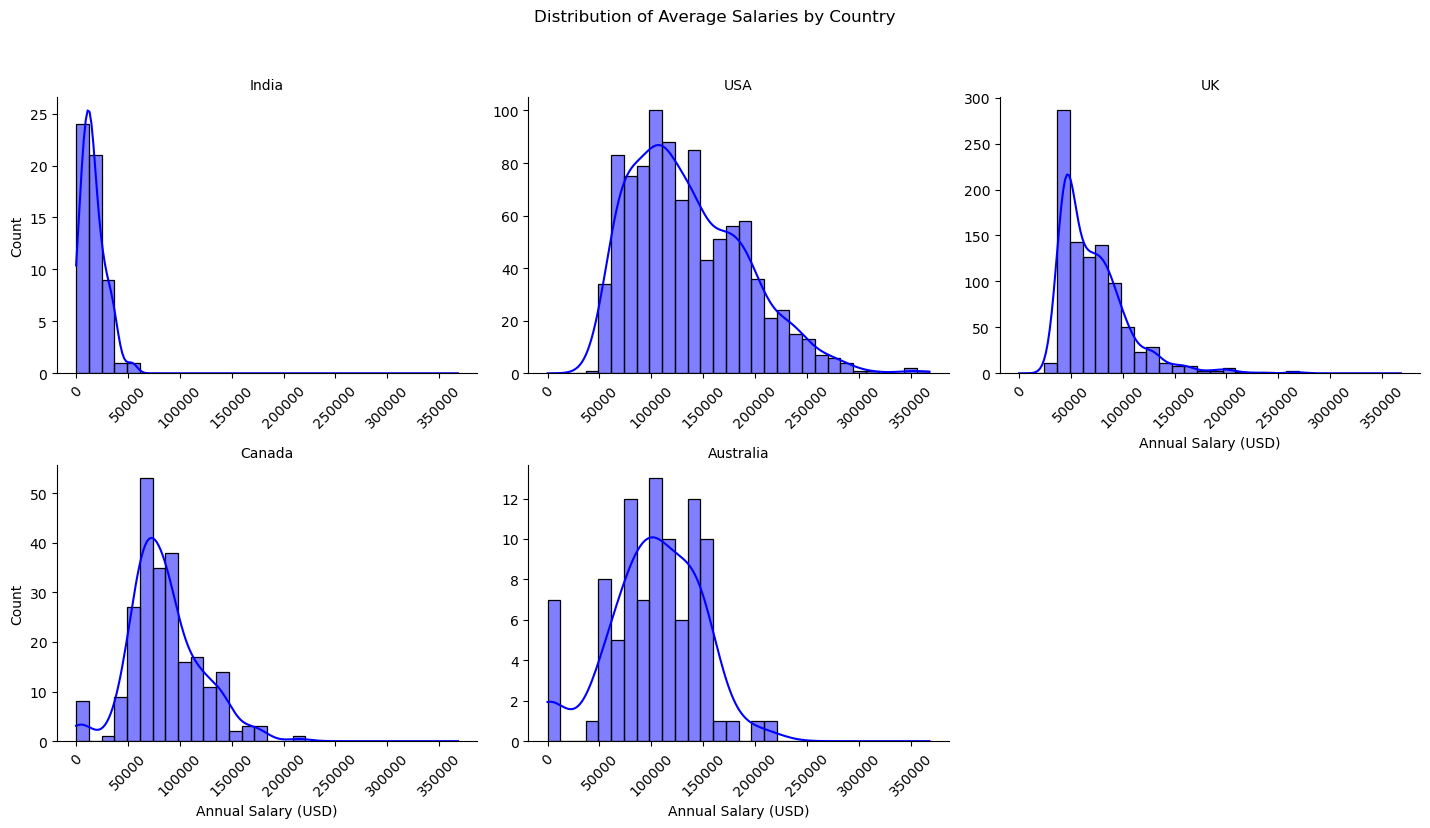

In [30]:
# Keep only valid positive salaries
salary_plot = (
    silver.loc[
        silver["salary_avg_usd"].gt(0),
        ["country", "salary_avg_usd"]
    ]
    .dropna()
)

# Distribution plot
chart = sns.displot(
    data=salary_plot,
    x="salary_avg_usd",
    col="country",
    col_wrap=3,
    bins=30,
    kde=True,
    color="blue",
    height=4,
    aspect=1.2,
    facet_kws={
        "sharex": False,
        "sharey": False
    }
)

# Labels
chart.set_axis_labels(
    "Annual Salary (USD)"
    )

chart.set_titles("{col_name}")

# Rotate x-axis labels for every subplot
for ax in chart.axes.flatten():
    ax.tick_params(axis="x", rotation=45)

# Overall title
chart.fig.suptitle(
    "Distribution of Average Salaries by Country",
    y=1.03
)

plt.tight_layout()
plt.show()

**Insight**
Salary skewness for India, 

In [31]:
# Summarize & calculate Skewness for each country
salary_summary = (
    salary_plot.groupby("country")
    .agg(
        salary_records=("salary_avg_usd", "count"),
        mean_salary=("salary_avg_usd", "mean"),
        median_salary=("salary_avg_usd", "median"),
        minimum_salary=("salary_avg_usd", "min"),
        maximum_salary=("salary_avg_usd", "max"),
        skewness=("salary_avg_usd", "skew"),
    )
    .round(2)
)

display(salary_summary)

,salary_records,mean_salary,median_salary,minimum_salary,maximum_salary,skewness
country,,,,,,
Australia,95,"102,344.73","105,263.16",6.58,"213,815.79",-0.42
Canada,238,"85,421.19","80,291.97",56.57,"214,963.50",0.49
India,56,"16,470.44","14,640.85",0.93,"53,782.72",0.97
UK,949,"71,831.49","64,477.86","30,927.71","266,666.67",1.83
USA,950,"135,280.84","126,332.88","43,449.42","368,271.97",0.76


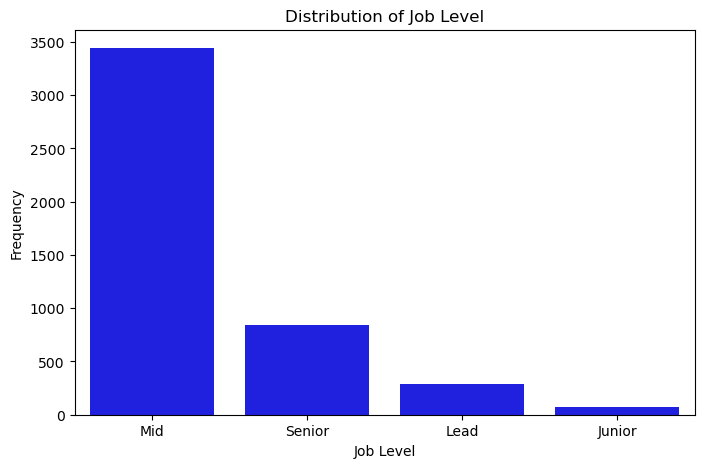

In [32]:
# Distribution of Job level
plt.figure(figsize=(8,5))

sns.countplot(
    data=silver,
    x="job_level",
    color="blue",
    order=df["job_level"].value_counts().index
)

plt.title("Distribution of Job Level")
plt.xlabel("Job Level")
plt.ylabel("Frequency")

plt.show()


### Bivariate Analysis

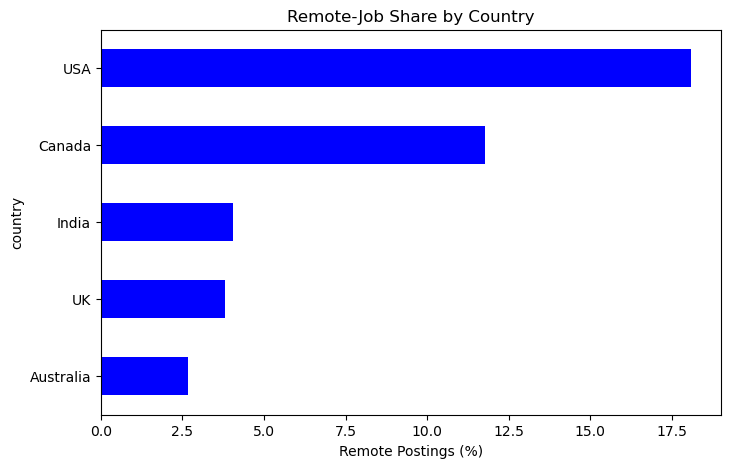

In [33]:
# Evaluating Remote Job postings by Country
remote_share = (
    silver.groupby("country")["is_remote"]
    .mean()
    .mul(100)
    .sort_values()
)

remote_share.plot(
    kind="barh",
    color="blue",
    figsize=(8, 5)
)

plt.title("Remote-Job Share by Country")
plt.xlabel("Remote Postings (%)")
plt.show()

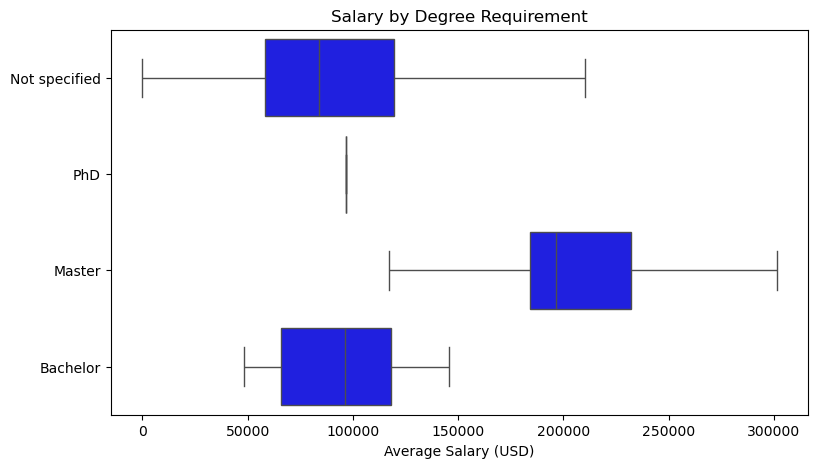

In [34]:
# Categorizing Salary by Degree Requirement 
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=silver,
    x="salary_avg_usd",
    y="degree_required",
    showfliers=False,
    color="blue"
)

plt.title("Salary by Degree Requirement")
plt.xlabel("Average Salary (USD)")
plt.ylabel("")
plt.show()

### Multivariate Analysis

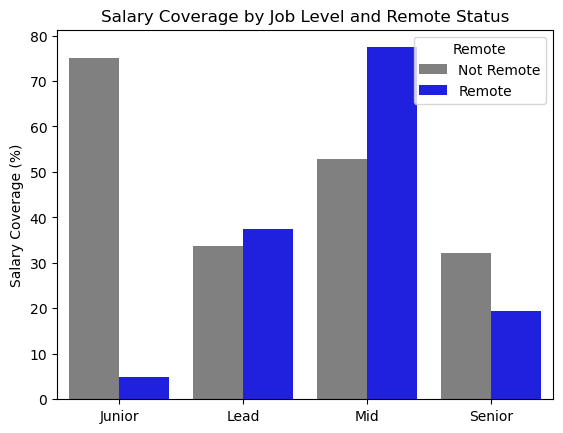

In [35]:

# Calculate salary coverage by job level and remote status
coverage_group = (
    silver.groupby(
        ["job_level", "is_remote"],
        observed=True
    )["has_salary"]
    .mean()
    .mul(100)
    .reset_index(name="coverage_pct")
)

# Give the Boolean values readable labels
coverage_group["remote_status"] = (
    coverage_group["is_remote"]
    .map({True: "Remote", False: "Not Remote"})
)

# Plot salary coverage
sns.barplot(
    data=coverage_group,
    x="job_level",
    y="coverage_pct",
    hue="remote_status",    
    palette={
        "Remote": "blue",
        "Not Remote": "grey"
    }
)

plt.title("Salary Coverage by Job Level and Remote Status")
plt.ylabel("Salary Coverage (%)")
plt.xlabel("")
plt.legend(title="Remote")
plt.show()

,country,total_postings,remote_postings,remote_share_pct
0,USA,950,172,18.11
1,UK,949,36,3.79
2,Canada,935,110,11.76
3,India,916,37,4.04
4,Australia,903,24,2.66


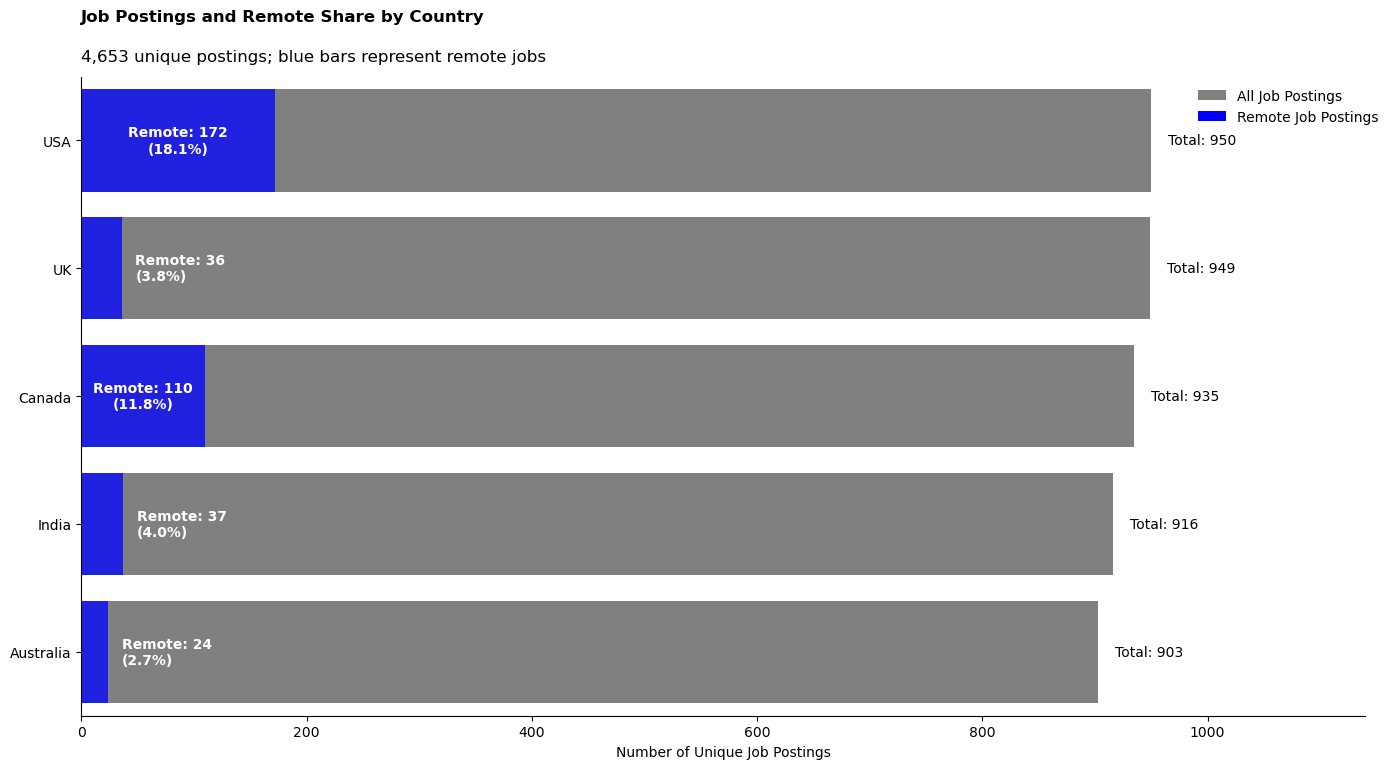

In [36]:
# Keep one record per job ID
posting_status = (
    silver[["job_id", "country", "is_remote"]]
    .drop_duplicates(subset="job_id")
    .copy()
)


# Standardize the different possible remote-status formats
remote_values = (
    posting_status["is_remote"]
    .astype("string")
    .str.strip()
    .str.lower()
)

remote_mapping = {
    "true": True,
    "false": False,
    "1": True,
    "0": False,
    "yes": True,
    "no": False,
}

posting_status["remote_flag"] = (
    remote_values.map(remote_mapping)
)


# Count total and remote postings by country
remote_by_country = (
    posting_status.groupby("country")
    .agg(
        total_postings=("job_id", "size"),
        remote_postings=("remote_flag", "sum"),
    )
    .assign(
        remote_share_pct=lambda frame: (
            100
            * frame["remote_postings"]
            / frame["total_postings"]
        )
    )
    .sort_values(
        "total_postings",
        ascending=False
    )
    .reset_index()
)

display(remote_by_country.round(2))


# Create the chart
fig, ax = plt.subplots(figsize=(14, 6))


# Grey bars represent all job postings
sns.barplot(
    data=remote_by_country,
    x="total_postings",
    y="country",
    color="grey",    
    ax=ax,
)


# Blue bars represent remote job postings
sns.barplot(
    data=remote_by_country,
    x="remote_postings",
    y="country",
    color="blue",
    ax=ax,
)


# Add labels
for position, row in remote_by_country.iterrows():

    # Total posting count
    ax.text(        
        row["total_postings"] + 15,
        position,
        f"Total: {int(row['total_postings']):,}",
        ha="left",
        va="center",
        color="black",
        fontsize=10,
    )

    # Position remote label according to bar length
    remote_count = row["remote_postings"]

    if remote_count >= 80:
        label_x = remote_count / 2
        label_alignment = "center"
        label_color = "white"
    else:
        label_x = remote_count + 12
        label_alignment = "left"
        label_color = "white"
        
    ax.text(        
        label_x,
        position,
        (
            f"Remote: {int(row['remote_postings']):,}\n"
            f"({row['remote_share_pct']:.1f}%)"
        ),
        ha=label_alignment,
        va="center",
        color=label_color,
        fontsize=10,
        fontweight="bold",
    )


# Format the chart
ax.set_title(
    "Job Postings and Remote Share by Country",
    loc="left",
    weight="bold",
    pad=40,
)

ax.set_xlabel("Number of Unique Job Postings")
ax.set_ylabel("")

ax.set_xlim(
    0,
    remote_by_country["total_postings"].max() * 1.20
)

# Add subtitle
ax.text(
    0,
    1.02,
    (
        f"{len(posting_status):,} unique postings; "
        "blue bars represent remote jobs"
    ),
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=12,
    color="black",
)


# Place legend outside the chart
legend_items = [
    Patch(
        facecolor="grey",        
        label="All Job Postings"
    ),
    Patch(
        facecolor="blue",        
        label="Remote Job Postings"
    ),
]

ax.legend(
    handles=legend_items,
    frameon=False,
    loc="upper right",
    bbox_to_anchor=(1.02, 1),
)

sns.despine(ax=ax)

# Reserve space on the right for the outside legend
fig.tight_layout(
    rect=[0, 0, 1, 1.3]
)


# Save the chart
fig.savefig(
    FIGURE_DIR / "02_job_postings_and_remote_share.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()

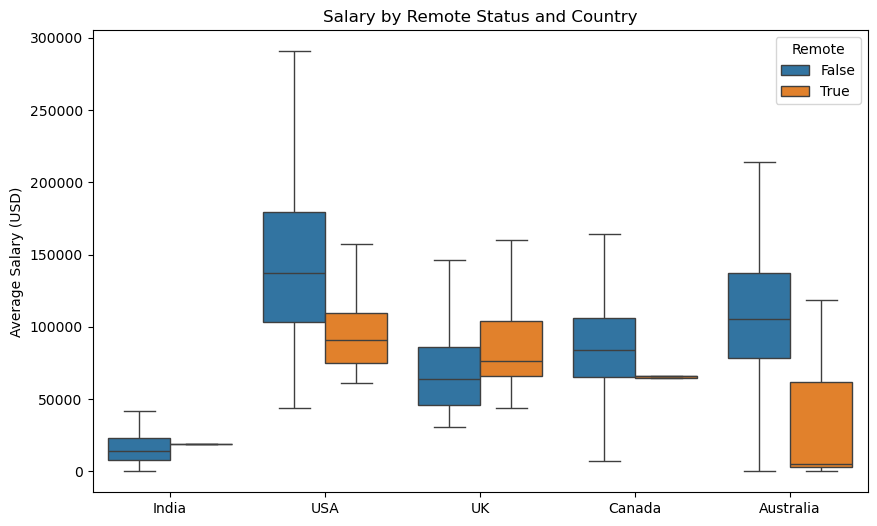

In [37]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=silver,
    x="country",
    y="salary_avg_usd",
    hue="is_remote",    
    showfliers=False
)

plt.title("Salary by Remote Status and Country")
plt.ylabel("Average Salary (USD)")
plt.xlabel("")
plt.legend(title="Remote")
plt.show()

,country,total_postings,salary_postings,coverage_pct
0,USA,950,950,100.00
1,UK,949,949,100.00
2,Canada,935,238,25.45
3,India,916,56,6.11
4,Australia,903,95,10.52


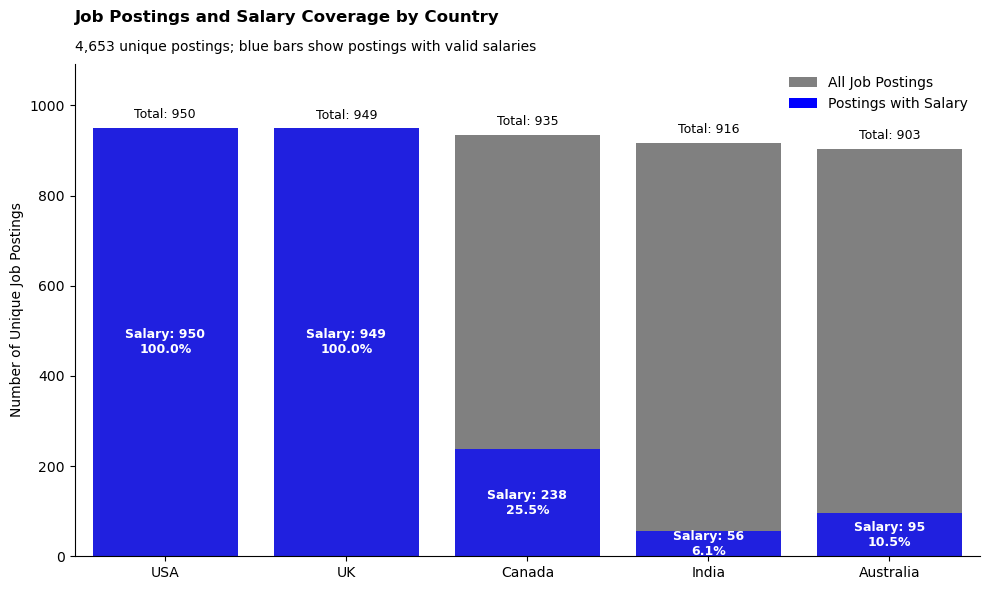

In [38]:
# Keep one record per job ID and identify salary availability
posting_status = (
    silver[["job_id", "country", "salary_avg_usd"]]
    .drop_duplicates(subset="job_id")
    .copy()
)

posting_status["has_salary"] = (
    posting_status["salary_avg_usd"].notna()
    & posting_status["salary_avg_usd"].gt(0)
)


# Count total postings and postings with salaries
coverage_by_country = (
    posting_status.groupby("country")
    .agg(
        total_postings=("job_id", "size"),
        salary_postings=("has_salary", "sum"),
    )
    .assign(
        coverage_pct=lambda frame: (
            100
            * frame["salary_postings"]
            / frame["total_postings"]
        )
    )
    .sort_values(
        "total_postings",
        ascending=False
    )
    .reset_index()
)

display(coverage_by_country.round(2))


# Create the chart
fig, ax = plt.subplots(figsize=(10, 6))

# Background bars represent all job postings
sns.barplot(data=coverage_by_country,
    x="country",
    y="total_postings",
    color="grey",
    ax=ax,
)

# Foreground bars represent postings with salary information
sns.barplot(data=coverage_by_country,
    x="country",
    y="salary_postings",
    color="blue",
    ax=ax,
)


# Add labels
for position, row in coverage_by_country.iterrows():

    # Total posting count above each bar
    ax.text(position,
        row["total_postings"] + 15,
        f"Total: {int(row['total_postings']):,}",
        ha="center",
        va="bottom",
        color="black",
        fontsize=9,
    )

    # Salary count and coverage inside the blue bar
    ax.text(position, row["salary_postings"] / 2,
        (
            f"Salary: {int(row['salary_postings']):,}\n"
            f"{row['coverage_pct']:.1f}%"
        ),
        ha="center",
        va="center",
        color="white",
        fontsize=9,
        fontweight="bold",
    )


# Chart formatting
ax.set_title(
    "Job Postings and Salary Coverage by Country",
    loc="left",
    weight="bold",
    pad=30,
)

ax.set_xlabel("")
ax.set_ylabel("Number of Unique Job Postings")

ax.set_ylim(0, coverage_by_country["total_postings"].max() * 1.15)

ax.text(0, 1.02,
    (
        f"{len(posting_status):,} unique postings; "
        "blue bars show postings with valid salaries"
    ),
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=10,
    color="black",
)


# Create a clear legend
legend_items = [
    Patch(facecolor="grey", label="All Job Postings"),
    Patch(facecolor="blue", label="Postings with Salary"),
]

ax.legend(handles=legend_items, frameon=False, loc="upper right")

sns.despine(ax=ax)
fig.tight_layout()

fig.savefig(
    FIGURE_DIR / "01_job_postings_and_salary_coverage.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()

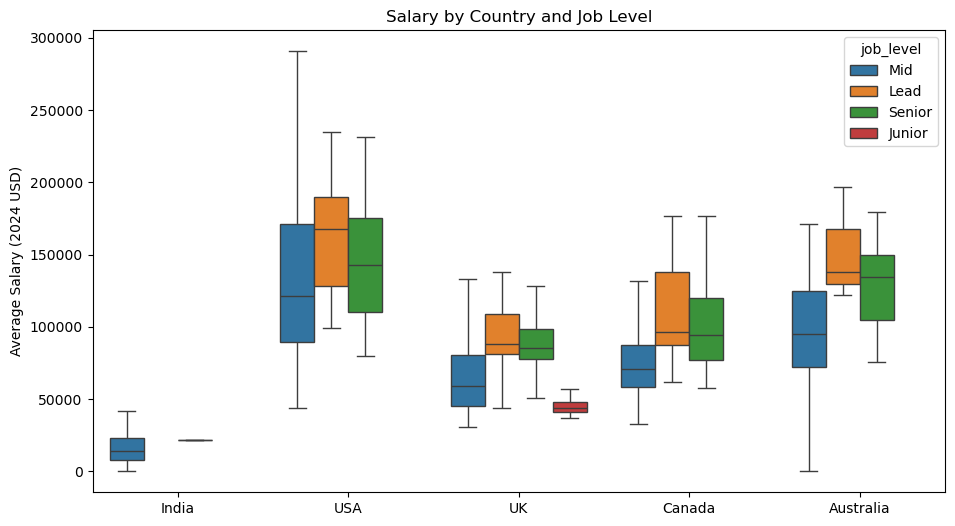

In [39]:
plt.figure(figsize=(11, 6))

sns.boxplot(
    data=silver,
    x="country",
    y="salary_avg_usd",
    hue="job_level",    
    showfliers=False
)

plt.title("Salary by Country and Job Level")
plt.ylabel("Average Salary (2024 USD)")
plt.xlabel("")
plt.show()

## Feature Engineering
Create:
- salary_range
- is_senior flag
- experience_tier bucket
- top skill binary flag

#### Create salary_range

In [40]:
# A salary range can only be calculated when both bounds exist
complete_salary_range = (
    silver[
        ["salary_min_usd", "salary_max_usd"]
    ]
    .notna()
    .all(axis=1)
)


# Calculate the salary range in USD
silver["salary_range_usd"] = (
    silver["salary_max_usd"]
    .sub(silver["salary_min_usd"])
    .where(complete_salary_range)
)


# Flag negative ranges as invalid
silver["salary_range_invalid"] = (
    complete_salary_range
    & silver["salary_range_usd"].lt(0)
)


print(
    "Rows with a calculated salary range:",
    silver["salary_range_usd"].notna().sum(),
)

print(
    "Rows with an invalid negative salary range:",
    silver["salary_range_invalid"].sum(),
)


# A negative range should not remain after salary cleaning
assert not silver["salary_range_invalid"].any(), (
    "At least one maximum salary is below its minimum salary."
)

Rows with a calculated salary range: 2284
Rows with an invalid negative salary range: 0


#### Validate salary_avg as midpoint of min and max

In [41]:
complete_salary_triplet = (
    silver[["salary_min_usd", "salary_avg_usd", "salary_max_usd"]]
    .notna().all(axis=1)
)


silver["salary_midpoint_usd_qa"] = (
    (silver["salary_min_usd"] + silver["salary_max_usd"]) / 2
).where(complete_salary_triplet)


silver["salary_midpoint_gap_usd_qa"] = (
    silver["salary_avg_usd"] - silver["salary_midpoint_usd_qa"]
).abs()


midpoint_mismatch = (
    complete_salary_triplet
    & ~np.isclose(silver["salary_avg_usd"], silver["salary_midpoint_usd_qa"],
        rtol=1e-7, atol=0.01)
)


print("Salary-average midpoint disagreements:", midpoint_mismatch.sum())

Salary-average midpoint disagreements: 0


#### Salary_range_summary

In [42]:
salary_range_summary = (
    silver.loc[silver["salary_range_usd"].notna()]
    .groupby(["country", "job_level"], observed=True)
    .agg(
        salary_records=("salary_range_usd", "size"),
        median_salary_range_usd=("salary_range_usd", "median"),
        mean_salary_range_usd=("salary_range_usd", "mean")).round(2)
)

display(salary_range_summary)

salary_records  median_salary_range_usd  \
country   job_level                                            
Australia Lead                    3                13,157.89   
          Mid                    72                13,157.89   
          Senior                 20                11,513.16   
Canada    Lead                   12                21,897.81   
          Mid                   152                18,248.18   
          Senior                 70                26,277.37   
India     Mid                    55                 8,366.20   
          Senior                  1                19,122.74   
UK        Junior                 40                     0.00   
          Lead                   51                     0.00   
          Mid                   747                     0.00   
          Senior                111                     0.00   
USA       Lead                   33                     0.00   
          Mid                   856                     0.00   
          Senior                 61                     0.00   

                     mean_salary_range_usd  
country   job_level                         
Australia Lead                   10,087.72  
          Mid                    15,113.95  
          Senior                 15,495.07  
Canada    Lead                   27,184.49  
          Mid                    21,655.15  
          Senior                 28,453.94  
India     Mid                    10,512.11  
          Senior                 19,122.74  
UK        Junior                  3,717.95  
          Lead                    2,388.13  
          Mid                     6,569.45  
          Senior                  2,114.55  
USA       Lead                    3,818.18  
          Mid                         0.00  
          Senior                      0.00

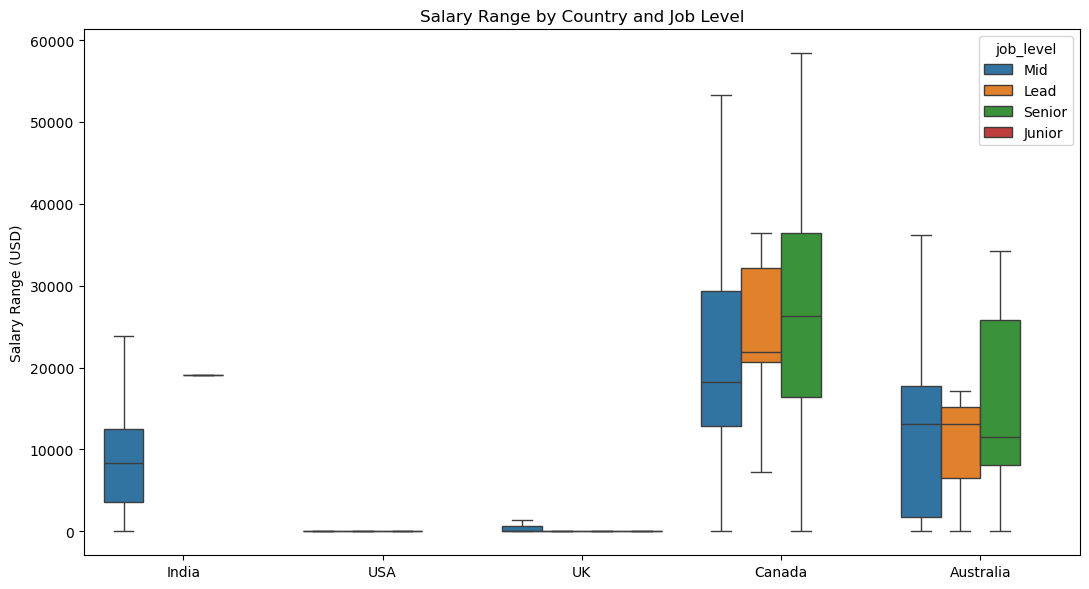

In [43]:
plt.figure(figsize=(11, 6))

sns.boxplot(
    data=silver,
    x="country",
    y="salary_range_usd",
    hue="job_level",
    showfliers=False,
)

plt.title("Salary Range by Country and Job Level")
plt.xlabel("")
plt.ylabel("Salary Range (USD)")
plt.tight_layout()
plt.show()

**Engineer Salary Range:**
`salary_range_usd` measures the difference between the maximum and minimum reported salaries:

**Salary range = Maximum salary − Minimum salary:**
The feature is calculated after currency conversion so that salary ranges are comparable across countries.

Because `salary_avg` is calculated from `salary_min` and `salary_max`, the range is closely connected to the target. It is therefore retained in the Silver layer for validation and EDA but excluded from the final model features to prevent target-related leakage problems.

In [44]:
# Preserve the original reported salary
silver["salary_avg_reported"] = silver["salary_avg"]


# Salary is available when the converted value is positive
silver["has_salary"] = (silver["salary_avg_usd"].notna()
    & silver["salary_avg_usd"].gt(0)
)


#### Seniority flag

In [45]:
# Confirm that job_level contains only expected categories
expected_job_levels = {
    "Junior",
    "Mid",
    "Senior",
    "Lead",
}

assert set(silver["job_level"].dropna().unique()) == expected_job_levels


# Senior and Lead roles receive 1;
# Junior and Mid roles receive 0.
silver["is_senior"] = (silver["job_level"].isin(["Senior", "Lead"])
    .astype("int8")
)


# Give the two groups readable segment labels
silver["salary_segment"] = (silver["is_senior"]
    .map({0: "Standard", 1: "Premium"})
)

In [46]:
seniority_check = pd.crosstab(
    silver["job_level"], silver["is_senior"], margins=True)

display(seniority_check)


assert (
    silver.loc[silver["job_level"].isin(["Senior", "Lead"]), "is_senior"]
    .eq(1)
    .all()
)


assert (
    silver.loc[
        silver["job_level"].isin(["Junior", "Mid"]), "is_senior"]
    .eq(0)
    .all()
)

is_senior,0,1,All
job_level,,,
Junior,72,0,72
Lead,0,293,293
Mid,3442,0,3442
Senior,0,846,846
All,3514,1139,4653


**Create Seniority Flag:**
The `is_senior` feature groups `Senior` and `Lead` positions into the project’s **Premium** segment. `Junior` and `Mid` positions form the **Standard** segment.

This simplifies comparisons of salary patterns and model accuracy between higher-seniority and standard roles.

#### Experience_tier flag

In [47]:
# Create the experience_tier
silver["experience_tier"] = pd.cut(
    silver["experience_required"],
    bins=[0, 2, 5, 10, 35],
    labels=[
        "Entry",
        "Intermediate",
        "Experienced",
        "Highly Experienced"        
    ],
    include_lowest=True,
)

silver["experience_tier"].value_counts(dropna=False)

experience_tier
NaN                   4221
Intermediate           159
Experienced            157
Highly Experienced      80
Entry                   36
Name: count, dtype: int64

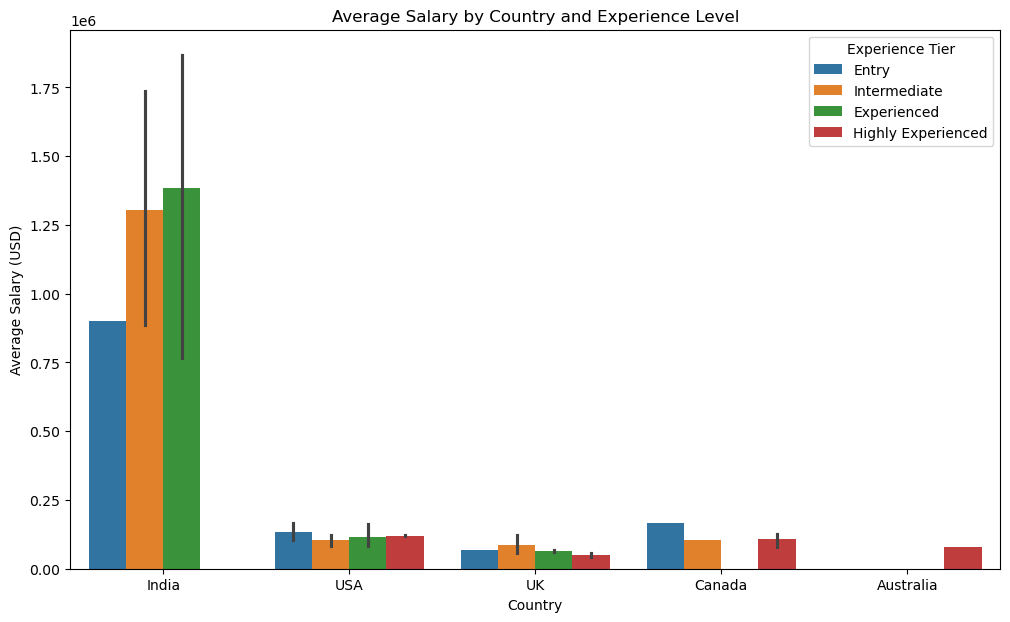

In [48]:
# Salary by Country and Experience tier
plt.figure(figsize=(12, 7))

sns.barplot(
    data=silver,
    x="country",
    y="salary_avg",    
    hue="experience_tier",
    errorbar=("ci", 95)
)

plt.title("Average Salary by Country and Experience Level")
plt.xlabel("Country")
plt.ylabel("Average Salary (USD)")
plt.legend(title="Experience Tier")

plt.show()

#### Create Skills binary

In [49]:
# Create binary flags for selected in-demand skills

silver["skill_python"] = (
    silver["skills"].str.contains("python", case=False, na=False).astype(int)
)

silver["skill_sql"] = (
    silver["skills"].str.contains("sql", case=False, na=False).astype(int)
)

silver["skill_spark"] = (
    silver["skills"].str.contains("spark", case=False, na=False).astype(int)
)

silver["skill_aws"] = (
    silver["skills"].str.contains("aws", case=False, na=False).astype(int)
)

silver["skill_excel"] = (
    silver["skills"].str.contains("excel", case=False, na=False).astype(int)
)

silver["skill_machine_learning"] = (
    silver["skills"].str.contains(
        "machine learning", case=False, na=False
    ).astype(int)
)

silver["skill_power_bi"] = (
    silver["skills"].str.contains("power bi", case=False, na=False).astype(int)
)

silver["skill_tableau"] = (
    silver["skills"].str.contains("tableau", case=False, na=False).astype(int)
)

In [50]:
skill_features = [
    "skill_python",
    "skill_sql",
    "skill_spark",
    "skill_aws",
    "skill_excel",
    "skill_machine_learning",
    "skill_power_bi",
    "skill_tableau"
]

display(silver[skill_features].head())

print(silver[skill_features].sum().sort_values(ascending=False))

,skill_python,skill_sql,skill_spark,skill_aws,skill_excel,skill_machine_learning,skill_power_bi,skill_tableau
0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0
2,0,0,0,0,0,1,0,0
3,0,0,0,0,0,0,0,0
4,0,0,0,0,0,1,0,0


skill_machine_learning    795
skill_python              277
skill_sql                 272
skill_excel               193
skill_aws                 104
skill_spark                85
skill_power_bi             37
skill_tableau              23
dtype: int64


## Data Preprocessing
### Training salary model
- divide the dataset into labels (X) and target (y)
- divide the dataset into train and test
- Ensure both X_train and y_train are in 2 dimension

In [51]:
# Records used to train the salary model
training_candidates = silver.loc[silver["has_salary"]].copy()


# Records requiring salary predictions
scoring_pool = silver.loc[~silver["has_salary"]].copy()


# Final prediction target
y = training_candidates["salary_avg_usd"]

#### One-Hot Encode the Required Categorical Features

`job_level`, `country`, and `is_remote` are categorical predictors. They are one-hot encoded inside the modelling pipeline after the train/test split.

The encoder is fitted only on the training data to prevent test-data information from influencing preprocessing. One reference category is dropped from each variable to avoid redundant dummy columns.

In [52]:
# Columns required for one-hot encoding
categorical_features = ["job_level", "country", "is_remote", "experience_tier"]


# Include num_skills without encoding it
numeric_features = ["experience_required", "num_skills", "skill_python", "skill_sql",
                    "skill_spark", "skill_aws", "skill_excel", "skill_machine_learning",
                   "skill_power_bi", "skill_tableau"]

feature_columns = (categorical_features + numeric_features)


#### Building the Training Model
- use the 80/20 development dataset.
- this will help in carrying out a 5-fold cross-validation of the data
- KFold would be used to stratify by country for both x and y

              FULL SALARY DATA
                    │
          stratify by country
                    │
          ┌─────────┴─────────┐
          ↓                   ↓
    80% DEVELOPMENT       20% TEST
      X_dev, y_dev       X_test, y_test
          │                   │
          ↓                   🔒
    5-Fold KFold
          │
          ↓
    Model comparison
          │
          ↓
    Model Diagnostics
    & Feature Assessment
          │
          ↓
    Hyperparameter tuning
          │
          ↓
     Best model
          │
          └──────────────→ 🔓 TEST
                                ↓
                          Final MAE/RMSE/R²

In [53]:
# DEVELOPMENT-TEST SPLIT

# Define Features X and Target y
# Create feature table
X = training_candidates[feature_columns].copy()

# Target variable
y = training_candidates["salary_avg_usd"].copy()


# Split the full dataset
# 80% = Development data
# 20% = Final untouched test data

X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=X["country"]
)


print("Development feature shape:", X_dev.shape)
print("Development target shape:", y_dev.shape)

print("\nFinal test feature shape:", X_test.shape)
print("Final test target shape:", y_test.shape) 

Development feature shape: (1830, 14)
Development target shape: (1830,)

Final test feature shape: (458, 14)
Final test target shape: (458,)


In [54]:
# Identifying Column types

numerical_columns = (X_dev.select_dtypes(include=[np.number]).columns.to_list())

categorical_columns = (X_dev.select_dtypes(exclude=[np.number]).columns.to_list())


print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['experience_required', 'num_skills', 'skill_python', 'skill_sql', 'skill_spark', 'skill_aws', 'skill_excel', 'skill_machine_learning', 'skill_power_bi', 'skill_tableau']

Categorical columns:
['job_level', 'country', 'is_remote', 'experience_tier']


In [55]:
# Verify our X and y
print(X.shape)
print(y.shape)

assert len(X) == len(y)
assert X.index.equals(y.index)

(2288, 14)
(2288,)


In [56]:
# Check X and y dimensions
X_dev.ndim

2

In [57]:
y_dev.ndim

1

#### Preprocessing and Encoding Categorical columns

In [58]:
# Here, preprocess & Encode Numerical columns
numerical_transformer = Pipeline(
    steps =[
        ('imputer', SimpleImputer(strategy="median")),
        ('scaler', StandardScaler())
    ]
)

# Preprocessing & Encoding of Categorical columns
categorical_transformer = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy="most_frequent")),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

# Combine both preprocessing pipelines
preprocess = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_columns),
        ('num', numerical_transformer, numerical_columns)
    ]
)

#### Defining 5-fold cross-validation

In [59]:
# 5-Fold Cross-Validation

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

### Base Pipeline

#### Linear Regression

In [60]:
# Build the LR Pipeline

linear_reg = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LinearRegression())
    ]
)


# Perform 5-fold cross-validation
linear_cv = cross_validate(
    linear_reg,
    X_dev,
    y_dev,
    cv=cv,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    },
    n_jobs=-1
)


# Convert negative errors to positive values
linear_mae = -linear_cv["test_MAE"]
linear_rmse = -linear_cv["test_RMSE"]
linear_r2 = linear_cv["test_R2"]


print("-----------------")
print("LINEAR REGRESSION")
print("-----------------")

print(f"Mean CV MAE:  ${linear_mae.mean():,.2f}")
print(f"Mean CV RMSE: ${linear_rmse.mean():,.2f}")
print(f"Mean CV R²:   {linear_r2.mean():.3f}")

-----------------
LINEAR REGRESSION
-----------------
Mean CV MAE:  $29,440.77
Mean CV RMSE: $39,665.39
Mean CV R²:   0.465


In [61]:
# Train the LR model by using X_dev and y_dev

from sklearn import set_config

set_config(display="diagram")

display(linear_reg)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the o

#### Random Forest

In [62]:
# Build the Random Forest Pipeline

random_forest = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(
            random_state=42
        ))
    ]
)


rf_cv = cross_validate(
    random_forest,
    X_dev,
    y_dev,
    cv=cv,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    },
    n_jobs=-1
)


rf_mae = -rf_cv["test_MAE"]
rf_rmse = -rf_cv["test_RMSE"]
rf_r2 = rf_cv["test_R2"]


print("-------------")
print("RANDOM FOREST")
print("-------------")

print(f"Mean CV MAE:  ${rf_mae.mean():,.2f}")
print(f"Mean CV RMSE: ${rf_rmse.mean():,.2f}")
print(f"Mean CV R²:   {rf_r2.mean():.3f}")

-------------
RANDOM FOREST
-------------
Mean CV MAE:  $27,051.62
Mean CV RMSE: $37,939.58
Mean CV R²:   0.510


In [63]:
# Train the RF model

from sklearn import set_config

set_config(display="diagram")

display(random_forest)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the o

#### Gradient Boost

In [64]:
# Build the Gradient Boost Pipeline

gradient_boost = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", GradientBoostingRegressor(
            random_state=42
        ))
    ]
)


# Evaluate the model using 5-fold cross-validation
gb_cv = cross_validate(
    gradient_boost,
    X_dev,
    y_dev,
    cv=cv,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    },
    n_jobs=-1
)


# Convert negative error scores to positive values
gb_mae = -gb_cv["test_MAE"]
gb_rmse = -gb_cv["test_RMSE"]
gb_r2 = gb_cv["test_R2"]


# Display results
print("-----------------")
print("GRADIENT BOOSTING")
print("-----------------")

print(f"Mean CV MAE:  ${gb_mae.mean():,.2f}")
print(f"Mean CV RMSE: ${gb_rmse.mean():,.2f}")
print(f"Mean CV R²:   {gb_r2.mean():.3f}")

-----------------
GRADIENT BOOSTING
-----------------
Mean CV MAE:  $27,155.20
Mean CV RMSE: $37,815.05
Mean CV R²:   0.513


In [65]:

set_config(display="diagram")

display(gradient_boost)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the o

In [66]:
# Compare the Cross-Validation performance of all models

model_results = pd.DataFrame({"Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],

    "CV_MAE": [
        linear_mae.mean(),
        rf_mae.mean(),
        gb_mae.mean()
    ],

    "CV_RMSE": [
        linear_rmse.mean(),
        rf_rmse.mean(),
        gb_rmse.mean()
    ],

    "CV_R2": [
        linear_r2.mean(),
        rf_r2.mean(),
        gb_r2.mean()
    ],

    "MAE_SD": [
        linear_mae.std(),
        rf_mae.std(),
        gb_mae.std()
    ]
})

# Rank models from lowest MAE to highest MAE
model_results = (
    model_results
    .sort_values("CV_MAE", ascending=True)
    .reset_index(drop=True)
)

display(model_results.round(2))

,Model,CV_MAE,CV_RMSE,CV_R2,MAE_SD
0,Random Forest,"27,051.62","37,939.58",0.51,"1,043.62"
1,Gradient Boosting,"27,155.20","37,815.05",0.51,"1,163.03"
2,Linear Regression,"29,440.77","39,665.39",0.46,"1,084.85"


#### Check if Engineered Features helped

In [67]:
model_features = categorical_features + numeric_features

scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    }

skill_columns = ['num_skills', 'skill_python', 
                 'skill_sql', 'skill_spark', 
                 'skill_aws', 'skill_excel', 
                 'skill_machine_learning', 
                 'skill_power_bi', 'skill_tableau'
                ]

def build_preprocessor(feature_list):
    categorical = [column for column in feature_list if column in categorical_features]
    numeric = [column for column in feature_list if column not in categorical]
    return ColumnTransformer([
        ("categorical", clone(categorical_transformer), categorical),
        ("numeric", clone(numerical_transformer), numeric),
    ])


core_features = ["job_level", "country", "is_remote", "experience_tier"]
feature_sets = {
    "Core": core_features,
    "Core + num_skills": core_features + ["num_skills"],
    "Core + skill flags": core_features + skill_columns,
    "All chosen features": model_features,
}

ablation_rows = []
for label, features in feature_sets.items():
    estimator = Pipeline([
        ("preprocess", build_preprocessor(features)),
        ("model", RandomForestRegressor(
            n_estimators=100, max_depth=10, random_state=42, n_jobs=1
        )),
    ])
    result = cross_validate(
        estimator,
        training_candidates.loc[X_dev.index, features],
        y_dev,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
    )
    ablation_rows.append({
        "Feature set": label,
        "CV_MAE": -result["test_MAE"].mean(),
        "CV_R2": result["test_R2"].mean(),
    })

ablation_results = pd.DataFrame(ablation_rows).sort_values("CV_MAE")
display(ablation_results.round(3))

,Feature set,CV_MAE,CV_R2
2,Core + skill flags,"26,947.01",0.52
3,All chosen features,"26,986.86",0.51
1,Core + num_skills,"27,865.13",0.49
0,Core,"30,645.98",0.40


## Model Diagnostics and Feature Assessment

The baseline regression models have now been trained and evaluated using MAE, RMSE, and R². 
Although Random Forest currently performs best, its prediction error is still higher than the 
existing business benchmark, while a substantial proportion of salary variation remains unexplained.

Before proceeding to hyperparameter tuning, it is therefore necessary to examine the model and 
the predictor variables more closely. This diagnostic stage is intended to identify whether model 
performance may be limited by weak or redundant features, multicollinearity, systematic prediction 
errors, or skewness in the target variable.

The assessment will therefore focus on:

- **Feature importance** to identify which predictors contribute most to salary prediction.
- **Multicollinearity and VIF** to detect redundant or strongly related predictors, particularly for Linear Regression.
- **Residual analysis** to determine where the model systematically overpredicts or underpredicts salaries.
- **Target skewness** to assess whether a transformation of salary may improve model performance.

The findings from these diagnostics will guide any subsequent feature selection, feature engineering, 
target transformation, and hyperparameter tuning.

In [68]:
# Fit-tune RF on Development data
best_rf = random_forest
best_rf.fit(X_dev, y_dev)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['job_level','country','is_remote',...,'skill_machine_learning', 'skill_power_bi','skill_tableau']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed throug

#### Calculate Permutation/Feature Importance

In [69]:
from sklearn.inspection import permutation_importance

# Permutation Importance
permutation_result = permutation_importance(
    best_rf,
    X_dev,
    y_dev,
    scoring="neg_mean_absolute_error",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

In [70]:
# Create feature importance table

feature_importance = pd.DataFrame({
    "Feature": X_dev.columns,
    "Importance": permutation_result.importances_mean,
    "Importance_SD": permutation_result.importances_std
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(feature_importance.round(2))

,Feature,Importance,Importance_SD
0,country,"20,006.68",621.77
1,skill_machine_learning,"5,012.60",348.86
2,job_level,"3,280.14",157.93
3,num_skills,"1,927.50",158.22
4,is_remote,"1,204.80",146.30
5,skill_python,581.64,58.25
6,experience_required,405.81,73.98
7,skill_excel,286.26,32.17
8,skill_sql,239.38,23.97
9,skill_aws,174.47,61.63


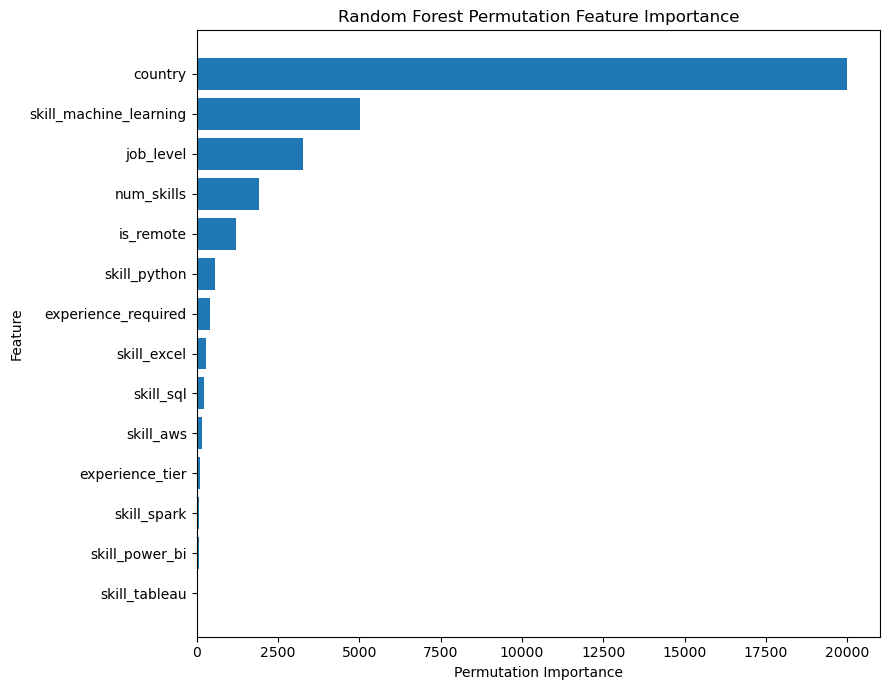

In [71]:
importance_plot = (
    feature_importance
    .sort_values("Importance", ascending=True)
)

plt.figure(figsize=(9, 7))

plt.barh(
    importance_plot["Feature"],
    importance_plot["Importance"]
)

plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title(
    "Random Forest Permutation Feature Importance"
)

plt.tight_layout()
plt.show()

**Interpretation:** Permutation importance indicates that country is the dominant predictor of salary in the Random Forest model, with substantially greater predictive contribution than all other variables. Machine-learning skill, job level, and the number of required skills also provide meaningful predictive information, while remote status has a smaller contribution. Most individual technical skills show relatively low importance, with Tableau, experience tier, Spark, Power BI, and AWS contributing little additional predictive information in the current model. However, low permutation importance should not immediately be interpreted as evidence that a feature should be removed, as correlated or redundant predictors may share predictive information. Further assessment of relationships among predictors is therefore required before feature-selection decisions are made.

### Multicollinearity and Variance Inflation Factor (VIF)

Following the feature importance assessment, relationships among the predictor
variables are examined to determine whether some features provide overlapping
or redundant information.

A correlation matrix is first used to identify strongly related numerical and
binary predictors. Variance Inflation Factor (VIF) is then used to quantify
the extent to which selected predictors can be explained by the other
predictors.

This assessment is particularly relevant to Linear Regression, where severe
multicollinearity can make coefficient estimates unstable. It also helps
interpret feature importance in the tree-based models.

In [72]:
# Select numerical and binary predictors for correlation analysis

corr_features = [
    "experience_required",
    "num_skills",
    "is_remote",
    "skill_python",
    "skill_sql",
    "skill_spark",
    "skill_aws",
    "skill_excel",
    "skill_machine_learning",
    "skill_power_bi",
    "skill_tableau"
]

X_corr = X_dev[corr_features].copy()

In [73]:
# Calculate correlation matrix

corr_matrix = (X_corr.corr().round(2))

display(corr_matrix)

,experience_required,num_skills,is_remote,skill_python,skill_sql,skill_spark,skill_aws,skill_excel,skill_machine_learning,skill_power_bi,skill_tableau
experience_required,1.00,-0.26,-0.12,-0.22,-0.01,-0.06,0.09,-0.09,-0.33,NaN,NaN
num_skills,-0.26,1.00,-0.15,0.59,0.56,0.33,0.30,0.27,0.58,0.17,0.20
is_remote,-0.12,-0.15,1.00,-0.06,-0.04,-0.03,-0.04,-0.05,-0.13,-0.03,-0.02
skill_python,-0.22,0.59,-0.06,1.00,0.54,0.23,0.11,0.02,-0.04,-0.02,0.04
skill_sql,-0.01,0.56,-0.04,0.54,1.00,0.21,0.04,0.02,-0.07,0.11,0.16
skill_spark,-0.06,0.33,-0.03,0.23,0.21,1.00,0.17,-0.02,0.03,-0.01,-0.00
skill_aws,0.09,0.30,-0.04,0.11,0.04,0.17,1.00,0.00,0.07,-0.01,-0.01
skill_excel,-0.09,0.27,-0.05,0.02,0.02,-0.02,0.00,1.00,-0.09,0.02,0.05
skill_machine_learning,-0.33,0.58,-0.13,-0.04,-0.07,0.03,0.07,-0.09,1.00,-0.04,-0.02
skill_power_bi,NaN,0.17,-0.03,-0.02,0.11,-0.01,-0.01,0.02,-0.04,1.00,0.43


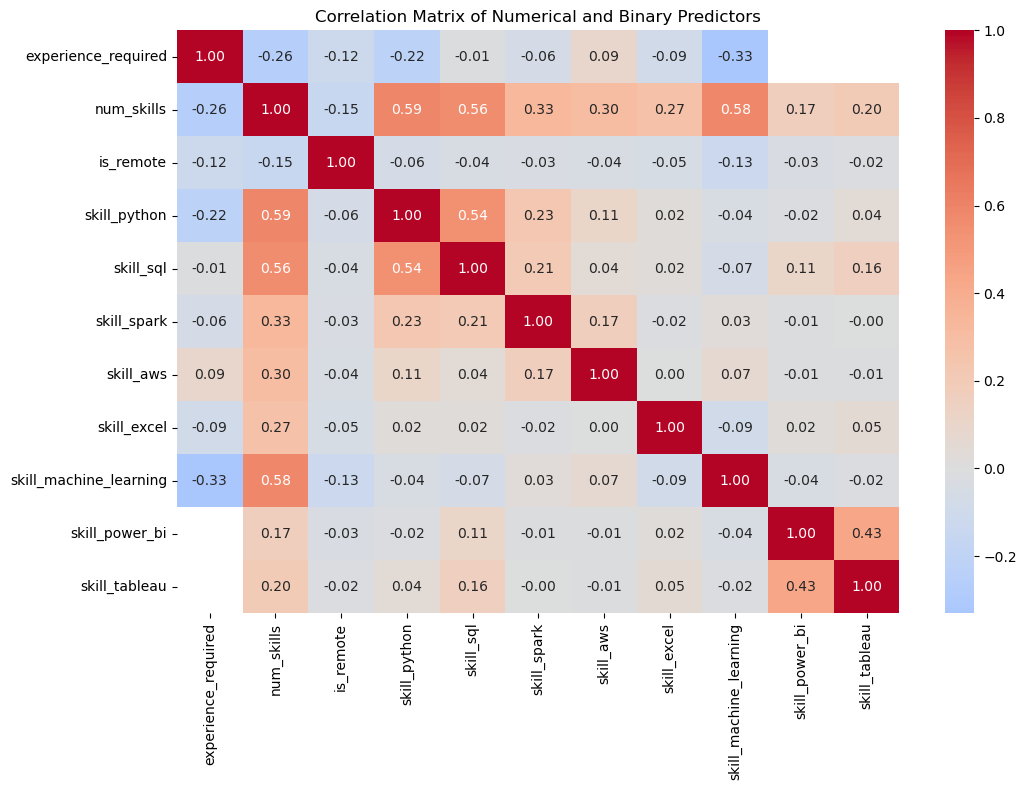

In [74]:
# Plot correlation heatmap

plt.figure(figsize=(11, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Matrix of Numerical and Binary Predictors"
)

plt.tight_layout()
plt.show()

In [75]:
# Prepare data for VIF analysis

X_vif = X_dev[corr_features].copy()

# Convert boolean columns to integers
X_vif = X_vif.astype(float)

# Impute missing values using median
X_vif = X_vif.fillna(X_vif.median())

In [76]:
# Calculate Variance Inflation Factor

vif_results = pd.DataFrame({
    "Feature": X_vif.columns,
    
    "VIF": [
        variance_inflation_factor(
            X_vif.values,
            i
        )
        for i in range(X_vif.shape[1])
    ]
})

vif_results = (
    vif_results
    .sort_values(
        "VIF",
        ascending=False
    )
    .reset_index(drop=True)
)

display(vif_results.round(2))

C:\Users\tatej\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
0,num_skills,inf
1,skill_python,inf
2,skill_sql,inf
3,skill_spark,inf
4,skill_aws,inf
5,skill_excel,inf
6,skill_machine_learning,inf
7,skill_power_bi,inf
8,skill_tableau,inf
9,experience_required,1.50


**Verification of Redundancy Between `num_skills` and Individual Skill Features**

The initial VIF assessment produced infinite (`inf`) values for `num_skills` and all individual skill indicator variables. This suggests the presence of **perfect multicollinearity**, where one predictor may be an exact linear combination of other predictors.

Since `num_skills` represents the total number of identified skills associated with each job posting, while the individual skill features (`skill_python`, `skill_sql`, `skill_spark`, `skill_aws`, `skill_excel`, `skill_machine_learning`, `skill_power_bi`, and `skill_tableau`) are binary indicators, it is necessary to determine whether `num_skills` is simply the sum of these individual skill variables.

To verify this, the individual skill indicators are summed for each observation and compared with the existing `num_skills` variable. A difference of zero across all observations would confirm that `num_skills` is an exact linear combination of the individual skill indicators and therefore explain the infinite VIF values.

This verification will guide the subsequent multicollinearity assessment and help determine whether `num_skills` should be treated as a redundant predictor.

In [77]:
# Sum all individual skill indicators

skill_columns = [
    "skill_python",
    "skill_sql",
    "skill_spark",
    "skill_aws",
    "skill_excel",
    "skill_machine_learning",
    "skill_power_bi",
    "skill_tableau"
]

skill_sum = X_dev[skill_columns].sum(axis=1)

# Compare the calculated sum with num_skills
comparison = pd.DataFrame({
    "num_skills": X_dev["num_skills"],
    "calculated_skill_sum": skill_sum
})

comparison["difference"] = (
    comparison["num_skills"]
    - comparison["calculated_skill_sum"]
)

display(comparison.head(10))

print(
    "Rows where values differ:",
    (comparison["difference"] != 0).sum()
)

,num_skills,calculated_skill_sum,difference
1715,0,0,0
2581,1,1,0
2264,1,1,0
1205,0,0,0
2039,0,0,0
1824,0,0,0
3231,0,0,0
2792,0,0,0
2457,0,0,0
1009,1,1,0


Rows where values differ: 0


In [78]:
# Recalculate VIF without num_skills

vif_features_reduced = [
    "experience_required",
    "is_remote",
    "skill_python",
    "skill_sql",
    "skill_spark",
    "skill_aws",
    "skill_excel",
    "skill_machine_learning",
    "skill_power_bi",
    "skill_tableau"
]

X_vif_reduced = X_dev[vif_features_reduced].copy()

X_vif_reduced = X_vif_reduced.astype(float)

X_vif_reduced = X_vif_reduced.fillna(
    X_vif_reduced.median()
)

vif_reduced = pd.DataFrame({
    "Feature": X_vif_reduced.columns,
    "VIF": [
        variance_inflation_factor(
            X_vif_reduced.values,
            i
        )
        for i in range(X_vif_reduced.shape[1])
    ]
})

vif_reduced = (
    vif_reduced
    .sort_values("VIF", ascending=False)
    .reset_index(drop=True)
)

display(vif_reduced.round(2))

,Feature,VIF
0,skill_sql,1.56
1,skill_python,1.56
2,experience_required,1.50
3,skill_tableau,1.25
4,skill_power_bi,1.25
5,skill_machine_learning,1.25
6,is_remote,1.12
7,skill_spark,1.10
8,skill_aws,1.06
9,skill_excel,1.05


**Interpretation of the Multicollinearity Assessment**

The initial VIF analysis produced infinite values for `num_skills` and the individual skill indicator variables, indicating perfect linear dependence among these predictors. Further assessment showed that this relationship was associated with the inclusion of `num_skills` alongside the individual skill features.

After excluding `num_skills` from the VIF assessment, all remaining predictors produced low VIF values, ranging from approximately 1.05 to 1.56. These values are well below commonly used thresholds for problematic multicollinearity, indicating that the remaining numerical and binary predictors do not exhibit substantial linear redundancy.

The result therefore suggests that the earlier infinite VIF values were not evidence of widespread multicollinearity across the predictor set, but were associated specifically with the relationship between `num_skills` and the individual skill indicators.

This finding is important for subsequent feature assessment. Although `num_skills` may contain useful predictive information, its relationship with the individual skill variables should be considered when interpreting model coefficients and feature importance, particularly for linear regression models. No individual skill predictor is removed at this stage solely on the basis of VIF.

### Residual Analysis

Following the feature importance and multicollinearity assessments, residual analysis is performed to examine the prediction errors of the selected Random Forest model.

A residual represents the difference between the actual and predicted salary:

**Residual = Actual Salary − Predicted Salary**

A positive residual indicates that the model **underpredicted** the salary, while a negative residual indicates that the model **overpredicted** the salary.

To avoid evaluating prediction errors on observations used to train the model, out-of-fold predictions are generated using the same 5-fold cross-validation structure applied during model development. Each observation in the development dataset is therefore predicted by a model that was not trained on that observation.

The analysis will examine the distribution and pattern of residuals to determine whether prediction errors appear random or whether the model systematically overpredicts or underpredicts particular salary ranges.

In [79]:
from sklearn.model_selection import cross_val_predict

# OUT-OF-FOLD PREDICTIONS FOR RESIDUAL ANALYSIS

# Use the tuned Random Forest model
best_rf = random_forest

# Generate out-of-fold predictions
y_dev_pred = cross_val_predict(
    best_rf,
    X_dev,
    y_dev,
    cv=cv,
    n_jobs=-1
)

In [80]:
# Create Residual Diagnostic table

residual_diagnostics = X_dev.copy()

residual_diagnostics["actual_salary"] = y_dev
residual_diagnostics["predicted_salary"] = y_dev_pred

# Residual = Actual - Predicted
residual_diagnostics["residual"] = (
    residual_diagnostics["actual_salary"]
    - residual_diagnostics["predicted_salary"]
)

# Absolute prediction error
residual_diagnostics["absolute_error"] = (
    residual_diagnostics["residual"].abs()
)

display(
    residual_diagnostics[
        [
            "actual_salary",
            "predicted_salary",
            "residual",
            "absolute_error"
        ]
    ].head(10).round(2)
)

,actual_salary,predicted_salary,residual,absolute_error
1715,"103,281.52","147,321.04","-44,039.52","44,039.52"
2581,"53,691.96","88,460.60","-34,768.63","34,768.63"
2264,"86,410.37","124,818.39","-38,408.02","38,408.02"
1205,"98,096.10","94,177.69","3,918.41","3,918.41"
2039,"67,252.71","88,887.00","-21,634.29","21,634.29"
1824,"60,468.52","113,506.42","-53,037.90","53,037.90"
3231,"85,583.94","76,658.54","8,925.40","8,925.40"
2792,"46,292.78","64,069.81","-17,777.03","17,777.03"
2457,"91,758.71","64,167.91","27,590.80","27,590.80"
1009,"124,458.27","186,954.43","-62,496.16","62,496.16"


In [81]:
residual_summary = (
    residual_diagnostics[
        [
            "actual_salary",
            "predicted_salary",
            "residual",
            "absolute_error"
        ]
    ]
    .describe()
    .round(2)
)

display(residual_summary)

,actual_salary,predicted_salary,residual,absolute_error
count,"1,830.00","1,830.00","1,830.00","1,830.00"
mean,"99,439.49","99,305.97",133.51,"27,051.62"
std,"54,394.79","40,564.99","38,021.92","26,711.31"
min,0.93,"8,851.23","-140,051.13",2.45
25%,"60,066.88","64,654.21","-20,394.52","9,556.15"
50%,"86,404.95","93,632.50","-5,680.69","19,296.11"
75%,"128,289.47","116,107.00","15,323.73","36,411.99"
max,"368,271.97","228,649.65","238,768.83","238,768.83"


In [82]:
mean_residual = residual_diagnostics["residual"].mean()

print(f"Mean Residual: ${mean_residual:,.2f}")

Mean Residual: $133.51


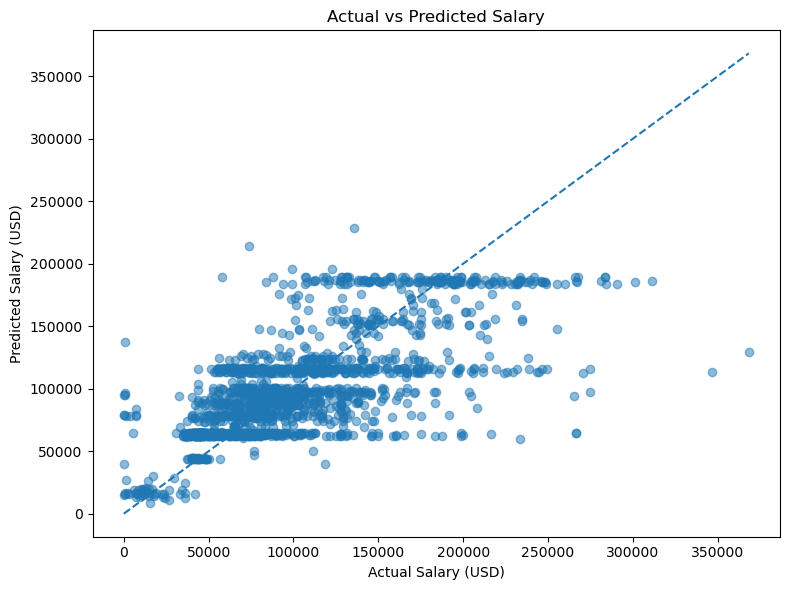

In [83]:
# Actual vs Predicted salary

plt.figure(figsize=(8, 6))

plt.scatter(
    residual_diagnostics["actual_salary"],
    residual_diagnostics["predicted_salary"],
    alpha=0.5
)

# Perfect prediction line
min_salary = min(
    residual_diagnostics["actual_salary"].min(),
    residual_diagnostics["predicted_salary"].min()
)

max_salary = max(
    residual_diagnostics["actual_salary"].max(),
    residual_diagnostics["predicted_salary"].max()
)

plt.plot(
    [min_salary, max_salary],
    [min_salary, max_salary],
    linestyle="--"
)

plt.xlabel("Actual Salary (USD)")
plt.ylabel("Predicted Salary (USD)")
plt.title("Actual vs Predicted Salary")

plt.tight_layout()
plt.show()

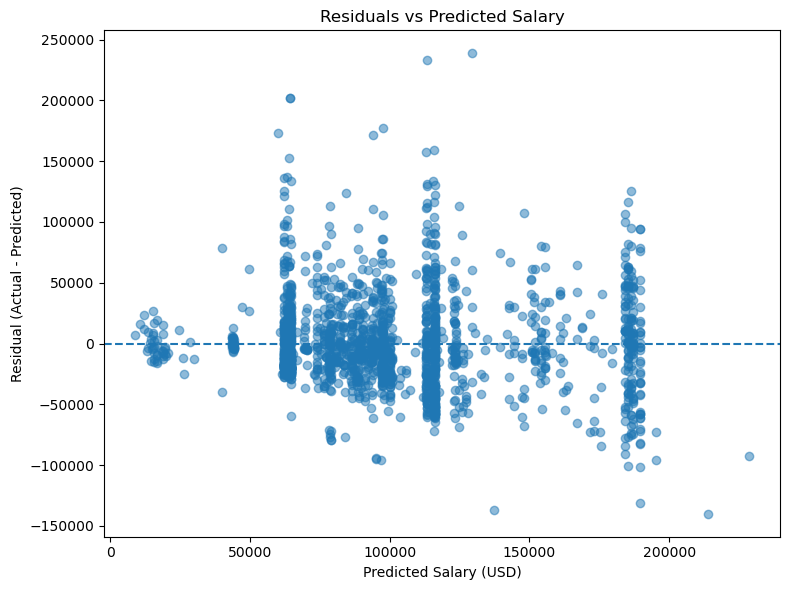

In [84]:
# Residual vs Predicted Salary

plt.figure(figsize=(8, 6))

plt.scatter(
    residual_diagnostics["predicted_salary"],
    residual_diagnostics["residual"],
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Salary (USD)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs Predicted Salary")

plt.tight_layout()
plt.show()

#### Testing underprediction vs overprediction

In [85]:
underpredicted = (
    residual_diagnostics["residual"] > 0
).sum()

overpredicted = (
    residual_diagnostics["residual"] < 0
).sum()

total = len(residual_diagnostics)

print(
    f"Underpredicted: "
    f"{underpredicted:,} "
    f"({underpredicted / total * 100:.2f}%)"
)

print(
    f"Overpredicted:  "
    f"{overpredicted:,} "
    f"({overpredicted / total * 100:.2f}%)"
)

Underpredicted: 760 (41.53%)
Overpredicted:  1,070 (58.47%)


In [86]:
# Largest Prediction Error

largest_errors = (
    residual_diagnostics
    .sort_values(
        "absolute_error",
        ascending=False
    )
    .head(20)
)

display(
    largest_errors[
        [
            "country",
            "job_level",
            "experience_tier",
            "is_remote",
            "actual_salary",
            "predicted_salary",
            "residual",
            "absolute_error"
        ]
    ].round(2)
)

,country,job_level,experience_tier,is_remote,actual_salary,predicted_salary,residual,absolute_error
1501,USA,Senior,NaN,False,"368,271.97","129,503.14","238,768.83","238,768.83"
1375,USA,Mid,NaN,False,"346,485.12","113,506.42","232,978.70","232,978.70"
1986,UK,Mid,Intermediate,False,"266,666.67","64,314.63","202,352.03","202,352.03"
1987,UK,Mid,Intermediate,False,"266,666.67","64,314.63","202,352.03","202,352.03"
1607,USA,Mid,NaN,True,"274,659.60","97,707.24","176,952.36","176,952.36"
2575,UK,Mid,NaN,True,"233,333.33","60,159.04","173,174.30","173,174.30"
1324,USA,Mid,NaN,True,"265,379.56","94,177.69","171,201.87","171,201.87"
1411,USA,Mid,NaN,False,"274,666.66","115,722.33","158,944.33","158,944.33"
1346,USA,Mid,NaN,False,"270,435.20","112,874.75","157,560.45","157,560.45"
2419,UK,Mid,NaN,False,"216,666.67","64,069.81","152,596.85","152,596.85"


Examine and identify extreme low and high salaries as shown by the calculated **prediction error**


In [87]:
# Inspect lowest salaries

lowest_salaries = (
    training_candidates
    .sort_values("salary_avg_usd")
    .head(20)
)

display(
    lowest_salaries[
        [
            "country",
            "job_title",
            "job_level",
            "salary_min",
            "salary_max",
            "salary_avg_usd"
        ]
    ]
)

,country,job_title,job_level,salary_min,salary_max,salary_avg_usd
913,India,business analyst,Mid,12.00,144.00,0.93
4094,Australia,data governance analyst,Mid,9.00,11.00,6.58
4574,Australia,ai business analyst,Mid,65.00,74.00,45.72
3568,Canada,business analyst,Mid,75.00,80.00,56.57
3650,Canada,"business analyst, temporary",Mid,75.00,80.00,56.57
3847,Australia,data analytics and data science intern remote,Mid,200.00,200.00,131.58
904,India,business analyst,Mid,"35,000.00","50,000.00",507.95
4416,Australia,senior software engineer mobile sdk development,Senior,850.00,900.00,575.66
4121,Australia,data engineer,Mid,"1,000.00","1,000.00",657.89
4463,Australia,business analyst,Mid,"1,000.00","1,000.00",657.89


In [88]:
# Inspect highest salaries

highest_salaries = (
    training_candidates
    .sort_values(
        "salary_avg_usd",
        ascending=False
    )
    .head(20)
)

display(
    highest_salaries[
        [
            "country",
            "job_title",
            "job_level",
            "salary_min",
            "salary_max",
            "salary_avg_usd"
        ]
    ]
)

,country,job_title,job_level,salary_min,salary_max,salary_avg_usd
1501,USA,machine learning engineer/senior machine learn...,Senior,"368,271.97","368,271.97","368,271.97"
1608,USA,lead machine learning engineer,Lead,"351,796.20","351,796.20","351,796.20"
1375,USA,distinguished data engineer,Mid,"346,485.12","346,485.12","346,485.12"
1655,USA,principal machine learning engineer,Mid,"311,533.00","311,533.00","311,533.00"
1627,USA,staff machine learning engineer,Mid,"301,249.78","301,249.78","301,249.78"
1647,USA,staff machine learning engineer,Mid,"290,671.88","290,671.88","290,671.88"
1512,USA,machine learning engineer,Mid,"284,288.00","284,288.00","284,288.00"
1513,USA,machine learning engineer,Mid,"283,726.78","283,726.78","283,726.78"
1635,USA,staff machine learning engineer,Mid,"283,616.97","283,616.97","283,616.97"
1625,USA,staff machine learning engineer,Mid,"282,111.16","282,111.16","282,111.16"


**Interpretation of Residual Analysis**

The residual analysis indicates that the Random Forest model does not make prediction errors uniformly across the salary distribution. Although approximately 58.36% of observations were overpredicted and 41.64% were underpredicted, the largest absolute errors were predominantly associated with substantial underprediction of high-salary observations.

Several high-salary observations, particularly among USA and UK job postings, produced large positive residuals, suggesting that the model tends to predict these observations closer to the central salary range rather than capturing their extreme values. This behaviour may contribute to the relatively high RMSE observed during model evaluation.

The analysis also identified potentially anomalous low-salary observations. For example, a Senior-level Australian job with an actual annual salary of approximately **USD575.66** was predicted at approximately **USD137,270**, producing an absolute error exceeding **USD136,000**. Such observations require further investigation because they may reflect currency-conversion, salary-unit, or other data-quality issues rather than genuine model failure.

Therefore, before considering target transformation or further model refinement, extreme salary observations are audited to distinguish legitimate salary variation from potential data-quality problems.

### Flag Detected Abnormal Salaries 

In [89]:
# ============================================================
# FLAG SALARY OUTLIERS WITHIN EACH COUNTRY
# ============================================================

def flag_salary_outliers(group):
    
    q1 = group["salary_avg_usd"].quantile(0.25)
    q3 = group["salary_avg_usd"].quantile(0.75)
    
    iqr = q3 - q1
    
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)
    
    group["salary_lower_bound"] = lower_bound
    group["salary_upper_bound"] = upper_bound
    
    group["salary_outlier"] = (
        (group["salary_avg_usd"] < lower_bound) |
        (group["salary_avg_usd"] > upper_bound)
    )
    
    return group


salary_audit = (
    training_candidates
    .groupby("country", group_keys=False)
    .apply(flag_salary_outliers)
)

print(salary_audit["salary_outlier"]
    .value_counts()
)

salary_outlier
False    2240
True       48
Name: count, dtype: int64


C:\Users\tatej\AppData\Local\Temp\ipykernel_25760\284559754.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(flag_salary_outliers)


In [90]:
# CREATE SALARY OUTLIER AUDIT TABLE

# Display all salary observations flagged as outliers

salary_outlier_audit = (
    salary_audit
    .loc[salary_audit["salary_outlier"]]
    .sort_values(
        ["country", "salary_avg_usd"],
        ascending=[True, False]
    )
)

display(
    salary_outlier_audit[
        [
            "job_title",
            "company",
            "country",
            "job_level",
            "salary_min",
            "salary_max",
            "salary_avg",
            "salary_avg_usd",
            "salary_lower_bound",
            "salary_upper_bound"
        ]
    ].round(2)
)

,job_title,company,country,job_level,salary_min,salary_max,salary_avg,salary_avg_usd,salary_lower_bound,salary_upper_bound
3514,senior staff machine learning platform engineer,Faire,Canada,Senior,"248,000.00","341,000.00","294,500.00","214,963.50","5,532.85","163,687.59"
3453,lead machine learning engineer,Serve Robotics,Canada,Lead,"225,000.00","260,000.00","242,500.00","177,007.30","5,532.85","163,687.59"
3503,"senior machine learning engineer, dash agentic ai",Dropbox,Canada,Senior,"205,700.00","278,300.00","242,000.00","176,642.34","5,532.85","163,687.59"
3261,"staff data engineer, analytics data engineering",Dropbox,Canada,Mid,"204,000.00","276,000.00","240,000.00","175,182.48","5,532.85","163,687.59"
3460,senior/principal machine learning engineer,Workday,Canada,Senior,"188,000.00","282,000.00","235,000.00","171,532.85","5,532.85","163,687.59"
2959,director of analytics & data science,Super.com,Canada,Mid,"195,000.00","268,000.00","231,500.00","168,978.10","5,532.85","163,687.59"
3525,"senior engineering manager, ai/ml",Remitly,Canada,Senior,"200,000.00","250,000.00","225,000.00","164,233.58","5,532.85","163,687.59"
2836,data scientist,V15P1Talonnn,Canada,Mid,"4,500.00","6,000.00","5,250.00","3,832.12","5,532.85","163,687.59"
3587,business analyst,Maarut,Canada,Mid,"2,080.00","2,080.00","2,080.00","1,518.25","5,532.85","163,687.59"
3568,business analyst,Sapsol Technologies Inc,Canada,Mid,75.00,80.00,77.50,56.57,"5,532.85","163,687.59"


In [91]:
# Number of salary outliers by country

outliers_by_country = (
    salary_outlier_audit
    ["country"]
    .value_counts()
    .to_frame("Outliers")
)

display(outliers_by_country)

,Outliers
country,
UK,31
Canada,11
USA,5
India,1


In [92]:
display(salary_audit.loc[[4416]])

,job_id,job_title,company,location,salary_min,salary_max,description,country,search_keyword,experience_required,degree_required,skills,num_skills,job_level,is_remote,...,skill_spark,skill_sql,skill_tableau,skills_extracted,salary_range_usd,salary_range_invalid,salary_midpoint_usd_qa,salary_midpoint_gap_usd_qa,salary_avg_reported,is_senior,salary_segment,experience_tier,salary_lower_bound,salary_upper_bound,salary_outlier
4416,5709019205,senior software engineer mobile sdk development,Balance Recruitment,"Sydney CBD, Sydney",850.00,900.00,Our client is a Global Cyber Security product ...,Australia,machine learning engineer,NaN,Not specified,[],0,Senior,False,...,0,0,0,0,32.89,False,575.66,0.00,875.00,1,Premium,NaN,"-12,417.76","226,398.03",False


In [93]:
# Identify suspiciously low annual salaries

low_salary_audit = (
    salary_audit
    .loc[salary_audit["salary_avg_usd"] < 10_000]
    .sort_values("salary_avg_usd")
)

display(
    low_salary_audit[
        [
            "job_title",
            "company",
            "country",
            "salary_min",
            "salary_max",
            "salary_avg",
            "salary_avg_usd"
        ]
    ]
)

,job_title,company,country,salary_min,salary_max,salary_avg,salary_avg_usd
913,business analyst,Ixora Global Services,India,12.00,144.00,78.00,0.93
4094,data governance analyst,Michael Page,Australia,9.00,11.00,10.00,6.58
4574,ai business analyst,Onpoint 365,Australia,65.00,74.00,69.50,45.72
3650,"business analyst, temporary",Aviso Wealth,Canada,75.00,80.00,77.50,56.57
3568,business analyst,Sapsol Technologies Inc,Canada,75.00,80.00,77.50,56.57
3847,data analytics and data science intern remote,Business Web Solutions,Australia,200.00,200.00,200.00,131.58
904,business analyst,Novrelease,India,"35,000.00","50,000.00","42,500.00",507.95
4416,senior software engineer mobile sdk development,Balance Recruitment,Australia,850.00,900.00,875.00,575.66
4121,data engineer,Torch Professional Services Pty Ltd,Australia,"1,000.00","1,000.00","1,000.00",657.89
4463,business analyst,FourQuarters,Australia,"1,000.00","1,000.00","1,000.00",657.89


In [94]:
# Check extremely low salary thresholds

threshold_check = pd.DataFrame({
    "Threshold_USD": [1_000, 5_000, 10_000, 15_000, 20_000],
    "Records_Below": [
        (training_candidates["salary_avg_usd"] < threshold).sum()
        for threshold in [1_000, 5_000, 10_000, 15_000, 20_000]
    ]
})

display(threshold_check)

,Threshold_USD,Records_Below
0,1000,11
1,5000,17
2,10000,32
3,15000,46
4,20000,54


In [95]:
# Flag threshold <10,000
# Flag implausibly low annual salaries

training_candidates["salary_implausibly_low"] = (
    training_candidates["salary_avg_usd"] < 10_000
)

training_candidates["salary_implausibly_low"].value_counts()

salary_implausibly_low
False    2256
True       32
Name: count, dtype: int64

In [96]:
# Remove implausibly low salary threshold
# and create cleaned modelling dataset
training_candidates_clean = (
    training_candidates
    .loc[~training_candidates["salary_implausibly_low"]]
    .copy()
)

print("Original observations:", len(training_candidates))

print("Removed observations:", training_candidates["salary_implausibly_low"].sum())

print("Remaining observations:", len(training_candidates_clean))

Original observations: 2288
Removed observations: 32
Remaining observations: 2256


**Treatment of Implausible Salary Observations**

The salary outlier audit showed that statistical outliers did not necessarily represent erroneous observations. Several high-salary records were associated with senior and/or lead positions and had internally consistent salary information. These observations are therefore considered plausible extreme salaries and retained.

In contrast, a small number of extremely low salary values are observed to be inconsistent with plausible annual compensations for the corresponding technology roles. These values may reflect salary-period differences, data-entry problems, or other inconsistencies in the original salary information.

Rather than removing all observations identified by the IQR procedure, a **targeted lower-salary screening** approach was therefore adopted. Observations with annual salaries below the selected plausibility threshold are flagged for review and excluded only where the values are considered implausible for the modelling objective.

No upper salary threshold was imposed solely on the basis of statistical extremity. This approach preserves potentially legitimate high-income observations while reducing distortion caused by implausibly low salary values.

### Target Skewness

In [97]:
# Create log-transformed salary for assessment ONLY

training_candidates_clean["salary_log"] = np.log1p(
    training_candidates_clean["salary_avg_usd"]
)

# Calculate skewness of cleaned original salary
clean_skewness =(
    training_candidates_clean["salary_avg_usd"]
    .skew()
)

log_skewness = (
    training_candidates_clean["salary_log"]
    .skew()
)

print(f"Original cleaned skewness: {clean_skewness:.3f}")
print(f"Log-transformed skewness:  {log_skewness:.3f}")

Original cleaned skewness: 1.119
Log-transformed skewness:  -0.242


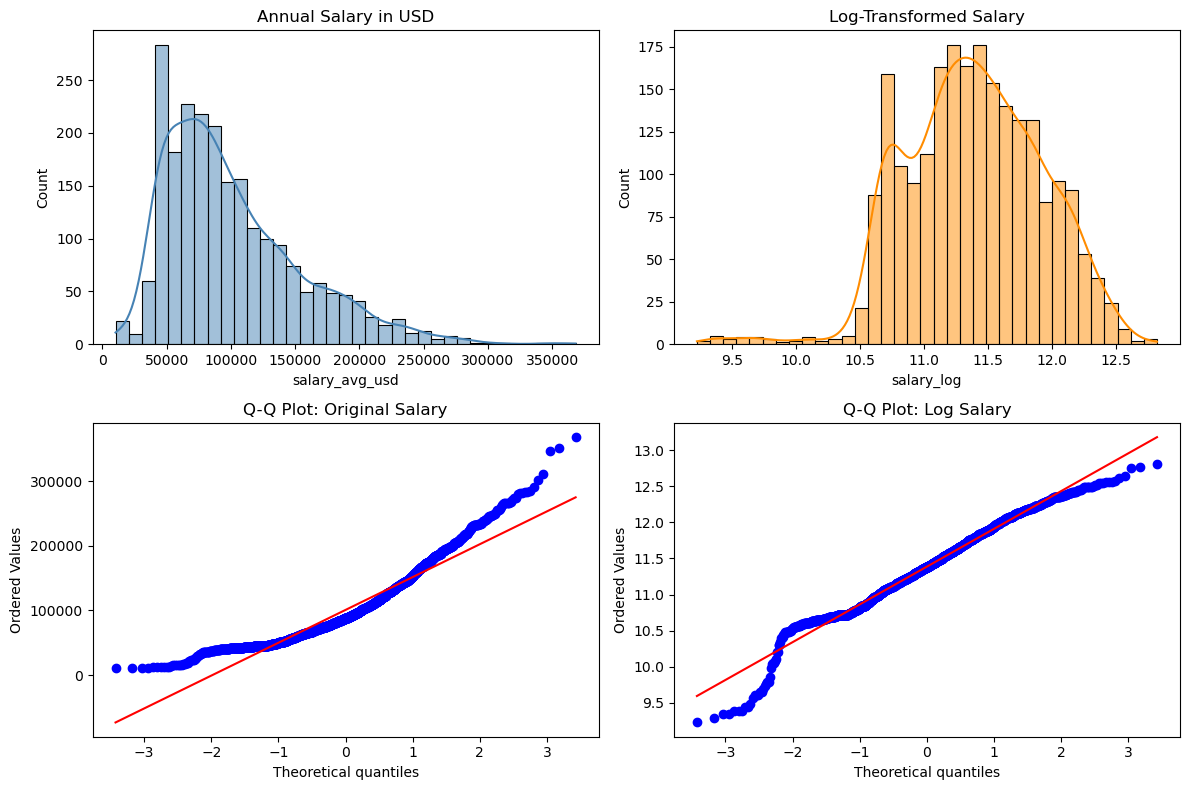

In [98]:
# Visualize Skewed and Log-transformed data

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Original salary distribution
sns.histplot(data=training_candidates_clean,
             x="salary_avg_usd", 
             bins=35, 
             kde=True, 
             ax=axes[0, 0], 
             color="steelblue"
            )
axes[0, 0].set_title("Annual Salary in USD")

# Log-transformed salary distribution
sns.histplot(data=training_candidates_clean,
             x="salary_log", 
             bins=35, 
             kde=True, 
             ax=axes[0, 1], 
             color="darkorange"
            )
axes[0, 1].set_title("Log-Transformed Salary")

# Q-Q plot: Original salary
stats.probplot(training_candidates_clean["salary_avg_usd"],                
               dist="norm", 
               plot=axes[1, 0]
              )
axes[1, 0].set_title("Q-Q Plot: Original Salary")

# Q-Q plot: Log-transformed salary
stats.probplot(training_candidates_clean["salary_log"],                
               dist="norm", 
               plot=axes[1, 1]
              )
axes[1, 1].set_title("Q-Q Plot: Log Salary")

plt.tight_layout()
plt.show()

### Interpretation of Target Transformation

Following the removal of implausibly low salary observations, the target variable remained positively skewed, with a skewness of 1.119. This indicates that the right-skewed distribution primarily reflects the presence of legitimate high-salary observations rather than the previously identified low-salary anomalies.

A logarithmic transformation using `log1p()` substantially reduced the skewness from 1.119 to -0.242. The transformed distribution is therefore considerably more symmetric, with only slight negative skewness.

However, improved distributional symmetry alone does not establish that the transformed target will produce a better predictive model. Tree-based models such as Random Forest do not require a normally distributed target, and the primary model evaluation metric remains MAE expressed in USD.

The original and log-transformed targets will therefore be compared using the same cross-validation framework. Predictions from the log-target model will be transformed back to the original USD scale before performance is evaluated. The target specification that provides better out-of-sample predictive performance will be retained.

In [99]:
# Original vs Log-target comparison

# Predictor variables
X_clean = training_candidates_clean[feature_columns].copy()

# Original salary target
y_original = (
    training_candidates_clean["salary_avg_usd"]
    .copy()
)

# Log-transformed salary target
y_log = np.log1p(y_original)


print("X shape:", X_clean.shape)
print("Original y shape:", y_original.shape)
print("Log y shape:", y_log.shape)

X shape: (2256, 14)
Original y shape: (2256,)
Log y shape: (2256,)


In [100]:
# Use the same 5-fold cross-validation
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

##### Random Forest

In [101]:
# Random Forest - Original salary Target

rf_original = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(
            random_state=42
        ))
    ]
)


# Generate out-of-fold predictions
pred_original = cross_val_predict(
    rf_original,
    X_clean,
    y_original,
    cv=cv,
    n_jobs=-1
)

In [102]:
mae_original = mean_absolute_error(
    y_original, pred_original)

print(f"Original Target CV MAE:", f"${mae_original:,.2f}")

Original Target CV MAE: $26,205.55


In [103]:
# Random Forest - Log salary Target

rf_log = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(
            random_state=42
        ))
    ]
)


# Generate predictions on the log scale
pred_log = cross_val_predict(
    rf_log,
    X_clean,
    y_log,
    cv=cv,
    n_jobs=-1
)

In [104]:
# Use the inverse of the log-transformation and convert to USD
pred_log_usd = np.expm1(pred_log)

pred_log_usd

array([ 21252.34275639,  16839.40840102,  14528.78467888, ...,
        95324.99616969,  95324.99616969, 129956.74494827], shape=(2256,))

In [105]:
# Calculate MAE
mae_log = mean_absolute_error(
    y_original, pred_log_usd)

print(f"Log Target CV MAE:", f"${mae_log:,.2f}")

Log Target CV MAE: $25,607.43


In [106]:
# Compare Original vs Log Target

target_comparison = pd.DataFrame({
    "Target": [
        "Original Salary",
        "Log-Transformed Salary"
    ],

    "CV_MAE_USD": [
        mae_original,
        mae_log
    ]
})

target_comparison = (
    target_comparison
    .sort_values(
        "CV_MAE_USD",
        ascending=True
    )
    .reset_index(drop=True)
)

display(
    target_comparison.round(2)
)

,Target,CV_MAE_USD
0,Log-Transformed Salary,"25,607.43"
1,Original Salary,"26,205.55"


### Target Selection & recreation for Final Modelling

The 5-fold cross-validation comparison showed that the log-transformed salary target achieved a lower MAE (**USD 25,607.43**) than the original salary target (**USD 26,205.55**). This indicates that reducing the influence of the right-skewed salary distribution provides a modest improvement in predictive performance.

Based on this result, the log-transformed salary (`salary_log`) will be adopted as the target variable for final model development. Model predictions will subsequently be converted back to the original USD scale using `expm1()` for final performance evaluation and interpretation.

In [107]:
# Final Modelling Dataset

# Predictor variables
X = training_candidates_clean[feature_columns].copy()

# Final Target: log-transformed annual salary
y = training_candidates_clean["salary_log"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2256, 14)
y shape: (2256,)


In [108]:
# Create the 80/20 (Dev-Test split)

X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=X["country"]
)

print("Development set:", X_dev.shape)
print("Final test set:", y_test.shape)

Development set: (1804, 14)
Final test set: (452,)


In [109]:
# Rebuild preprocessing from final X_dev

numerical_columns = (
    X_dev
    .select_dtypes(include=[np.number])
    .columns
    .to_list()
)

categorical_columns = (
    X_dev
    .select_dtypes(exclude=[np.number])
    .columns
    .to_list()
)

In [110]:
# Reuse the numerical and categorical transformers

preprocess = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_columns),
        ("num", numerical_transformer, numerical_columns)
    ]
)

In [111]:
# Rerun the Base pipeline models

# Linear Regression Pipeline
linear_reg = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LinearRegression())
    ]
)


# Random Forest Pipeline
random_forest = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(
            random_state=42
        ))
    ]
)


# Gradient Boosting Pipeline
gradient_boost = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", GradientBoostingRegressor(
            random_state=42
        ))
    ]
)


# Display the models
set_config(display="diagram")

display(linear_reg)
display(random_forest)
display(gradient_boost)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the o

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the o

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the o

In [112]:
# Generate 5-Fold predictions for each Baseline model

# Linear Regression
linear_pred_log = cross_val_predict(
    linear_reg,
    X_dev,
    y_dev,
    cv=cv,
    n_jobs=-1
)

# Random Forest
rf_pred_log = cross_val_predict(
    random_forest,
    X_dev,
    y_dev,
    cv=cv,
    n_jobs=-1
)

# Gradient Boosting
gb_pred_log = cross_val_predict(
    gradient_boost,
    X_dev,
    y_dev,
    cv=cv,
    n_jobs=-1
)

In [113]:
# Convert PREDICTIONS and ACTUAL SALARIES back to USD

# Convert log values back to USD

y_dev_usd = np.expm1(y_dev)

linear_pred_usd = np.expm1(linear_pred_log)
rf_pred_usd = np.expm1(rf_pred_log)
gb_pred_usd = np.expm1(gb_pred_log)

In [114]:
# Calculate MAE, RMSE, & R2

# Linear Regression
linear_mae = mean_absolute_error(y_dev_usd, linear_pred_usd)

linear_rmse = np.sqrt(
    mean_squared_error(y_dev_usd, linear_pred_usd)
)

linear_r2 = r2_score(y_dev_usd, linear_pred_usd)


# Random Forest
rf_mae = mean_absolute_error(y_dev_usd, rf_pred_usd)

rf_rmse = np.sqrt(
    mean_squared_error(y_dev_usd, rf_pred_usd)
)

rf_r2 = r2_score(y_dev_usd, rf_pred_usd)


# Gradient Boosting
gb_mae = mean_absolute_error(y_dev_usd, gb_pred_usd)

gb_rmse = np.sqrt(
    mean_squared_error(y_dev_usd, gb_pred_usd)
)

gb_r2 = r2_score(y_dev_usd, gb_pred_usd)

In [115]:
# Recreate the Model comparison

model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "CV_MAE_USD": [
        linear_mae,
        rf_mae,
        gb_mae
    ],

    "CV_RMSE_USD": [
        linear_rmse,
        rf_rmse,
        gb_rmse
    ],

    "CV_R2": [
        linear_r2,
        rf_r2,
        gb_r2
    ]
})

# Rank models from lowest MAE to highest MAE
model_results = (
    model_results
    .sort_values(
        "CV_MAE_USD",
        ascending=True
    )
    .reset_index(drop=True)
)

display(model_results.round(2))

,Model,CV_MAE_USD,CV_RMSE_USD,CV_R2
0,Random Forest,"26,119.22","37,640.36",0.50
1,Gradient Boosting,"26,508.28","38,198.70",0.49
2,Linear Regression,"27,994.64","39,499.36",0.45


#### Baseline Model Comparison After Target Transformation

Following salary cleaning and adoption of the log-transformed target, the three baseline regression models were re-evaluated using 5-fold cross-validation, with predictions converted back to the original USD scale before calculating the performance metrics.

Random Forest achieved the strongest baseline performance, with the lowest MAE (**USD 26,119.22**) and RMSE (**USD 37,640.36**), as well as the highest R² (**0.50**). Gradient Boosting performed closely behind, with an MAE of **USD 26,508.28** and R² of **0.49**, while Linear Regression produced the weakest performance.

The relatively small performance difference between Random Forest and Gradient Boosting suggests that both tree-based models remain competitive. Therefore, both models will proceed to hyperparameter tuning using the development data, while the final test set remains untouched.

### Hyperparameter Tuning

In [116]:
# Create USD-MAE Scorer

# Custom USD-MAE Scorer

from sklearn.metrics import make_scorer

def usd_mae(y_true_log, y_pred_log):
    
    # Convert actual and predicted values back to USD
    y_true_usd = np.expm1(y_true_log)
    y_pred_usd = np.expm1(y_pred_log)
    
    # Calculate MAE in USD
    return mean_absolute_error(
        y_true_usd,
        y_pred_usd
    )


usd_mae_scorer = make_scorer(
    usd_mae,
    greater_is_better=False
)

In [117]:
# Random Forest Hypertuning

rf_param_grid = {
    "model__n_estimators": [200, 300],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", 0.8]
}


rf_grid = GridSearchCV(
    estimator=random_forest,
    param_grid=rf_param_grid,
    scoring=usd_mae_scorer,
    cv=cv,
    n_jobs=-1,
    refit=True
)


rf_grid.fit(
    X_dev,
    y_dev
)

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

print(
    f"\nBest Random Forest CV MAE: "
    f"${-rf_grid.best_score_:,.2f}"
)

Best Random Forest Parameters:
{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 300}

Best Random Forest CV MAE: $26,017.90


In [118]:
# Gradient Boost Hypertuning

gb_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__subsample": [0.8, 1.0]
}


gb_grid = GridSearchCV(
    estimator=gradient_boost,
    param_grid=gb_param_grid,
    scoring=usd_mae_scorer,
    cv=cv,
    n_jobs=-1,
    refit=True
)


gb_grid.fit(
    X_dev,
    y_dev
)

print("Best Gradient Boosting Parameters:")
print(gb_grid.best_params_)

print(
    f"\nBest Gradient Boosting CV MAE: "
    f"${-gb_grid.best_score_:,.2f}"
)

Best Gradient Boosting Parameters:
{'model__learning_rate': 0.03, 'model__max_depth': 4, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 300, 'model__subsample': 0.8}

Best Gradient Boosting CV MAE: $26,071.76


In [119]:
tuning_results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Gradient Boosting"
    ],

    "Baseline_CV_MAE": [
        rf_mae,
        gb_mae
    ],

    "Tuned_CV_MAE": [
        -rf_grid.best_score_,
        -gb_grid.best_score_
    ]
})


tuning_results["MAE_Improvement"] = (
    tuning_results["Baseline_CV_MAE"]
    - tuning_results["Tuned_CV_MAE"]
)


tuning_results = (
    tuning_results
    .sort_values(
        "Tuned_CV_MAE",
        ascending=True
    )
    .reset_index(drop=True)
)

display(
    tuning_results.round(2)
)

,Model,Baseline_CV_MAE,Tuned_CV_MAE,MAE_Improvement
0,Random Forest,"26,119.22","26,017.90",101.32
1,Gradient Boosting,"26,508.28","26,071.76",436.52


#### Select Final Tuned Model

In [120]:
final_model = rf_grid.best_estimator_


# Predict log salary on fianl test data
y_test_pred_log = final_model.predict(X_test)


# Convert predictions back to USD
y_test_pred_usd = np.expm1(y_test_pred_log)


# Convert actual test target back to USD
y_test_usd = np.expm1(y_test)

In [121]:
# Calculate MAE, RMSE, & R2

final_mae = mean_absolute_error(
    y_test_usd,
    y_test_pred_usd
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_test_usd,
        y_test_pred_usd
    )
)

final_r2 = r2_score(
    y_test_usd,
    y_test_pred_usd
)

print(f"Final Test MAE:  ${final_mae:,.2f}")
print(f"Final Test RMSE: ${final_rmse:,.2f}")
print(f"Final Test R²:   {final_r2:.3f}")

Final Test MAE:  $23,374.50
Final Test RMSE: $32,385.28
Final Test R²:   0.610


### Final Model Evaluation

The tuned Random Forest model was evaluated on the previously untouched 20% test dataset to assess its ability to generalize to unseen observations. Predictions generated on the log-transformed scale were converted back to annual salary in USD using `expm1()` before calculating the final performance metrics.

The model achieved a final **MAE of USD 23,374.50**, indicating that predicted annual salaries differed from actual salaries by approximately USD 23,375 on average. The **RMSE of USD 32,385.28** indicates that some larger prediction errors remain, while the **R² of 0.610** shows that the model explains approximately 61% of the observed variation in salary within the test dataset.

The final test MAE was lower than the cross-validation MAE obtained during model development, suggesting that the selected model generalized well to the held-out test observations. Since the test dataset was not used during model training, model selection, or hyperparameter tuning, these results provide an independent estimate of the model's predictive performance.

**Based on these results, the tuned Random Forest pipeline is retained as the final salary prediction model and can proceed to the deployment stage.**

### Save the Fitted Pipeline

In [122]:
import joblib

joblib.dump(
    final_model,
    "salary_prediction_pipeline.pkl"
)

print("✅ Model pipeline saved successfully!")

joblib.dump(
    feature_columns,
    "feature_columns.pkl"
)

print("✅ Model Feature names saved successfully!")


✅ Model pipeline saved successfully!
✅ Model Feature names saved successfully!


In [123]:
# Test that Model reloads correctly

loaded_model = joblib.load(
    "salary_prediction_pipeline.pkl"
)

print("✅ Model loaded successfully.")

✅ Model loaded successfully.


In [124]:
# Verify using one observation

sample = X_test.iloc[[0]]

pred_log = loaded_model.predict(sample)

pred_usd = np.expm1(pred_log)

print(
    f"Predicted Salary: ${pred_usd[0]:,.2f}"
)

Predicted Salary: $43,818.84


### Build a Streamlit prediction interface

In [145]:
app_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import joblib


# ============================================================
# PAGE CONFIGURATION
# ============================================================

st.set_page_config(
    page_title="Tech Salary Predictor",
    page_icon="💼",
    layout="wide"
)


# ============================================================
# CUSTOM STYLE
# ============================================================

st.markdown(
    """
    <style>

    /* ========================================================
       PAGE
       ======================================================== */

    .stApp {
        background-color: #F8FAFC;
        color: #0F172A;
    }

    .block-container {
        padding-top: 2.5rem;
        padding-bottom: 2rem;
        max-width: 1200px;
    }


    /* ========================================================
       MAIN TITLE
       ======================================================== */

    .main-title {
        color: #0F172A !important;
        font-size: 2.5rem;
        font-weight: 700;
        margin-bottom: 0.2rem;
    }

    .subtitle {
        color: #64748B !important;
        font-size: 1rem;
        margin-bottom: 2rem;
    }


    /* ========================================================
       HEADINGS
       ======================================================== */

    h1, h2, h3 {
        color: #0F172A !important;
    }


    /* ========================================================
       NORMAL TEXT
       ======================================================== */

    p {
        color: #334155;
    }


    /* ========================================================
       INPUT LABELS
       ======================================================== */

    label,
    div[data-testid="stWidgetLabel"] p {
        color: #334155 !important;
        font-weight: 500;
    }


    /* ========================================================
       SELECT BOXES
       ======================================================== */
    
    div[data-testid="stSelectbox"] div[data-baseweb="select"] > div {
        background-color: #FFFFFF !important;
        color: #0F172A !important;
        border: 1px solid #CBD5E1 !important;
        border-radius: 8px !important;
    }
    
    div[data-testid="stSelectbox"] div[data-baseweb="select"] span {
        color: #0F172A !important;
    }
    
    div[data-testid="stSelectbox"] svg {
        fill: #475569 !important;
    }


   /* ========================================================
        NUMBER INPUT
      ======================================================== */
    
    div[data-testid="stNumberInput"] input {
        background-color: #FFFFFF !important;
        color: #0F172A !important;
    }
    
    div[data-testid="stNumberInput"] > div {
        background-color: #FFFFFF !important;
        border-color: #CBD5E1 !important;
    }
    
    div[data-testid="stNumberInput"] button {
        background-color: #F8FAFC !important;
        color: #334155 !important;
        border-color: #CBD5E1 !important;
    }
    
    div[data-testid="stNumberInput"] button svg {
        fill: #334155 !important;
    }


    /* ========================================================
       CHECKBOXES
       ======================================================== */
    
    div[data-testid="stCheckbox"] label p {
        color: #334155 !important;
    }
    
    div[data-testid="stCheckbox"] div[data-testid="stCheckbox"] {
        background-color: transparent !important;
    }
    
    div[data-testid="stCheckbox"] [role="checkbox"] {
        background-color: #FFFFFF !important;
        border: 1px solid #94A3B8 !important;
    }
    
    div[data-testid="stCheckbox"] [aria-checked="true"] {
        background-color: #2563EB !important;
        border-color: #2563EB !important;
    }


    /* ========================================================
       PRIMARY BUTTON
       ======================================================== */

    div.stButton > button[kind="primary"] {
        background-color: #2563EB !important;
        color: #FFFFFF !important;
        border: none !important;
        border-radius: 8px !important;
        font-weight: 600 !important;
        min-height: 46px;
        transition: all 0.2s ease;
    }

    div.stButton > button[kind="primary"] p {
        color: #FFFFFF !important;
        font-weight: 600 !important;
    }

    div.stButton > button[kind="primary"]:hover {
        background-color: #1D4ED8 !important;
        color: #FFFFFF !important;
        border: none !important;
    }

    div.stButton > button[kind="primary"]:hover p {
        color: #FFFFFF !important;
    }


    /* ========================================================
       SALARY RESULT CARD
       ======================================================== */

    div[data-testid="stMetric"] {
        background-color: #F0FDFA !important;
        padding: 30px;
        border-radius: 14px;
        border: 1px solid #99F6E4;
        box-shadow: 0 4px 12px rgba(15, 23, 42, 0.06);
    }

    div[data-testid="stMetricLabel"] {
        color: #475569 !important;
        font-weight: 500;
    }

    div[data-testid="stMetricValue"] {
        color: #0F766E !important;
        font-size: 2.6rem !important;
        font-weight: 700 !important;
    }


    /* ========================================================
       INFORMATION BOX
       ======================================================== */

    div[data-testid="stAlert"] {
        background-color: #EFF6FF !important;
        border: 1px solid #BFDBFE !important;
        border-radius: 10px;
    }

    div[data-testid="stAlert"] p {
        color: #1E3A8A !important;
    }


    /* ========================================================
       EXPANDER
       ======================================================== */

    div[data-testid="stExpander"] {
        background-color: #FFFFFF !important;
        border: 1px solid #E2E8F0 !important;
        border-radius: 10px !important;
    }

    div[data-testid="stExpander"] summary {
        background-color: #EFF6FF !important;
        color: #1E3A8A !important;
        border-radius: 10px !important;
    }

    div[data-testid="stExpander"] summary p {
        color: #1E3A8A !important;
        font-weight: 600 !important;
    }


    /* ========================================================
       TABLE
       ======================================================== */

    div[data-testid="stTable"] {
        background-color: #FFFFFF !important;
    }

    div[data-testid="stTable"] table {
        background-color: #FFFFFF !important;
        color: #0F172A !important;
    }

    div[data-testid="stTable"] th {
        background-color: #EFF6FF !important;
        color: #1E3A8A !important;
    }

    div[data-testid="stTable"] td {
        background-color: #FFFFFF !important;
        color: #334155 !important;
    }


    /* ========================================================
       DIVIDER AND FOOTER
       ======================================================== */

    hr {
        border-color: #E2E8F0 !important;
    }

    div[data-testid="stCaptionContainer"] {
        color: #64748B !important;
    }

    div[data-testid="stCaptionContainer"] p {
        color: #64748B !important;
    }

    </style>
    """,
    unsafe_allow_html=True
)


# ============================================================
# LOAD TRAINED MODEL
# ============================================================

model = joblib.load(
    "salary_prediction_pipeline.pkl"
)


# ============================================================
# HEADER
# ============================================================

st.markdown(
    '<div class="main-title">💼 Tech Job Salary Predictor</div>',
    unsafe_allow_html=True
)

st.markdown(
    '<div class="subtitle">'
    'Estimate annual salary from job characteristics, '
    'experience, and required technical skills.'
    '</div>',
    unsafe_allow_html=True
)


# ============================================================
# MAIN LAYOUT
# ============================================================

input_col, result_col = st.columns(
    [1.25, 1],
    gap="large"
)


# ============================================================
# LEFT COLUMN — INPUTS
# ============================================================

with input_col:

    st.subheader("Job Details")

    col1, col2 = st.columns(2)

    with col1:

        country = st.selectbox(
            "Country",
            [
                "USA",
                "UK",
                "Canada",
                "India",
                "Australia"
            ]
        )

        job_level = st.selectbox(
            "Job Level",
            [
                "Junior",
                "Mid",
                "Senior",
                "Lead"
            ]
        )

    with col2:

        is_remote = st.selectbox(
            "Remote Job?",
            [False, True]
        )

        experience_required = st.number_input(
            "Years of Experience Required",
            min_value=0.0,
            max_value=40.0,
            value=3.0,
            step=1.0
        )


    # ========================================================
    # DERIVE EXPERIENCE TIER AUTOMATICALLY
    # ========================================================

    if experience_required <= 2:
        experience_tier = "Entry"

    elif experience_required <= 5:
        experience_tier = "Intermediate"

    elif experience_required <= 10:
        experience_tier = "Experienced"

    else:
        experience_tier = "Highly Experienced"

    st.info(
        f"Experience Tier: {experience_tier}"
    )


    # ========================================================
    # REQUIRED SKILLS
    # ========================================================

    st.subheader("Required Skills")

    skill_col1, skill_col2 = st.columns(2)

    with skill_col1:

        skill_python = st.checkbox("Python")
        skill_sql = st.checkbox("SQL")
        skill_spark = st.checkbox("Spark")
        skill_aws = st.checkbox("AWS")

    with skill_col2:

        skill_excel = st.checkbox("Excel")
        skill_machine_learning = st.checkbox(
            "Machine Learning"
        )
        skill_power_bi = st.checkbox("Power BI")
        skill_tableau = st.checkbox("Tableau")


    # ========================================================
    # COUNT SELECTED SKILLS
    # ========================================================

    num_skills = sum([
        skill_python,
        skill_sql,
        skill_spark,
        skill_aws,
        skill_excel,
        skill_machine_learning,
        skill_power_bi,
        skill_tableau
    ])


    # ========================================================
    # BUILD MODEL INPUT
    # ========================================================

    input_data = pd.DataFrame({
        "job_level": [job_level],
        "country": [country],
        "is_remote": [is_remote],
        "experience_tier": [experience_tier],
        "experience_required": [experience_required],
        "num_skills": [num_skills],
        "skill_python": [int(skill_python)],
        "skill_sql": [int(skill_sql)],
        "skill_spark": [int(skill_spark)],
        "skill_aws": [int(skill_aws)],
        "skill_excel": [int(skill_excel)],
        "skill_machine_learning": [
            int(skill_machine_learning)
        ],
        "skill_power_bi": [
            int(skill_power_bi)
        ],
        "skill_tableau": [
            int(skill_tableau)
        ]
    })


    # ========================================================
    # PREDICTION BUTTON
    # ========================================================

    predict_button = st.button(
        "Predict Salary",
        type="primary",
        use_container_width=True
    )


# ============================================================
# RIGHT COLUMN — RESULTS
# ============================================================

with result_col:

    st.subheader("Salary Estimate")

    st.write(
        "Your predicted annual salary will appear here "
        "after you submit the job information."
    )

    if predict_button:

        predicted_log_salary = model.predict(
            input_data
        )[0]

        predicted_salary_usd = np.expm1(
            predicted_log_salary
        )

        st.metric(
            label="Estimated Annual Salary",
            value=f"${predicted_salary_usd:,.2f}"
        )

        st.caption(
            "Prediction generated using the final tuned "
            "Random Forest salary model."
        )

        st.info(
            f"The estimate is based on a "
            f"{job_level.lower()} role in {country}, "
            f"with {int(experience_required)} years of "
            f"required experience, classified as "
            f"{experience_tier}, and {num_skills} "
            f"selected technical skills."
        )

    else:

        st.info(
            "Complete the job information on the left "
            "and click Predict Salary."
        )


# ============================================================
# METHODOLOGY AND DATA NOTES
# ============================================================

with st.expander("ℹ️ Methodology and Data Notes"):

    st.markdown(
        """
        **Currency Standardization**

        Salary values from different countries were converted to USD using
        **2024 annual average official exchange rates**.

        **Source:** World Bank World Development Indicators  
        **Indicator:** **PA.NUS.FCRF** — Official exchange rate  
        **Definition:** Local Currency Units (LCU) per US$, period average  
        **Underlying source:** IMF International Financial Statistics
        """
    )

    exchange_rate_table = pd.DataFrame({
        "Country": [
            "USA",
            "UK",
            "Canada",
            "India",
            "Australia"
        ],
        "Currency": [
            "USD",
            "GBP",
            "CAD",
            "INR",
            "AUD"
        ],
        "LCU per USD": [
            1.00,
            0.78,
            1.37,
            83.67,
            1.52
        ],
        "Reference Year": [
            2024,
            2024,
            2024,
            2024,
            2024
        ]
    })

    st.table(
        exchange_rate_table
    )


# ============================================================
# FOOTER
# ============================================================

st.divider()

st.caption(
    "Tech Job Salary Prediction Model | "
    "Random Forest Regression | Predictions shown in USD"
)
'''

In [146]:
with open(
    "Salary_prediction_app.py",
    "w",
    encoding="utf-8"
) as file:
    file.write(app_code)

print("Streamlit app updated successfully.")

Streamlit app updated successfully.


In [147]:
import os

print(
    "Model file:",
    os.path.exists("salary_prediction_pipeline.pkl")
)

print(
    "App file:",
    os.path.exists("Salary_prediction_app.py")
)

Model file: True
App file: True


### Online Deployment

In [148]:
requirements = """streamlit
pandas
numpy
scikit-learn
joblib
"""

with open("requirements.txt", "w") as file:
    file.write(requirements)

print("requirements.txt created successfully.")

requirements.txt created successfully.


In [149]:
import os
print(os.getcwd())

C:\Users\tatej\OneDrive\10Alytics\Python\Machine Learning\Final Capstone Project
